In [1]:
# ============================================================
# COMPLETE MEMORY / CACHE / VARIABLE CLEANUP
# ============================================================

import os, gc, time, psutil
def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 66.87 MB
Variable count  : 13
Variables       : clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, delete_model_variables, force_garbage_collection, gc, get_ram_usage, get_user_variables, open, os, print_variable_information, psutil, time

[1] Closing Matplotlib figures...
    Matplotlib figures closed.

[2] Clearing TensorFlow / Keras...
    Keras session cleared.
    GPU:0 current: 0.00 MB
    GPU:0 peak   : 0.00 MB
    TensorFlow cleanup completed.

[3] Running garbage collection...
    Garbage-collected objects: 0

[4] Deleting user/model/data variables...
    Variables selected for deletion: 1
    Deleting: open
    Successfully deleted: 1

[5] Final garbage collection...
    Garbage-collected objects: 0

AFTER CLEANING
----------------------------------------------------------------------
RAM usage       : 847.

Total: 7023
Classes: ['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']
Distribution: (array([0, 1, 2, 3]), array([1621, 1645, 2000, 1757], dtype=int64))
Development: 6320
Test: 703

Extracting raw/domain features
Processed: 0
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
Processed: 5500
Processed: 6000
Processed: 6500
Processed: 7000
Raw/domain extraction: 1.31 min

FOLD 1
Epoch 1/50
158/158 [==============================] - 11s 47ms/step - loss: 1.0735 - accuracy: 0.4998 - val_loss: 0.9426 - val_accuracy: 0.5957
Epoch 2/50
158/158 [==============================] - 7s 44ms/step - loss: 0.7992 - accuracy: 0.6762 - val_loss: 0.7606 - val_accuracy: 0.7191
Epoch 3/50
158/158 [==============================] - 7s 45ms/step - loss: 0.6734 - accuracy: 0.7366 - val_loss: 0.6917 - val_accuracy: 0.7318
Epoch 4/50
158/158 [==============================] - 7s 45ms/step - loss: 0.5933

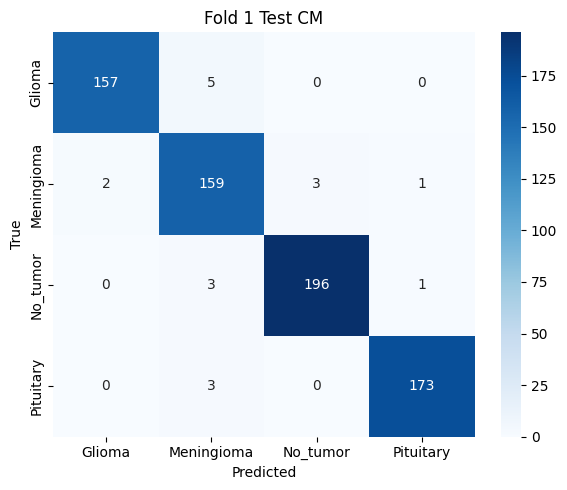

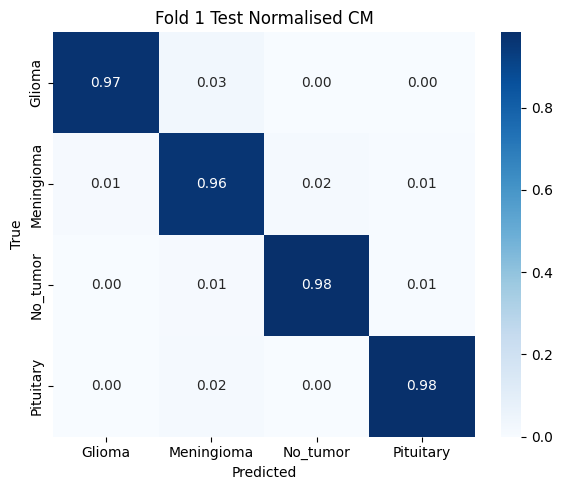

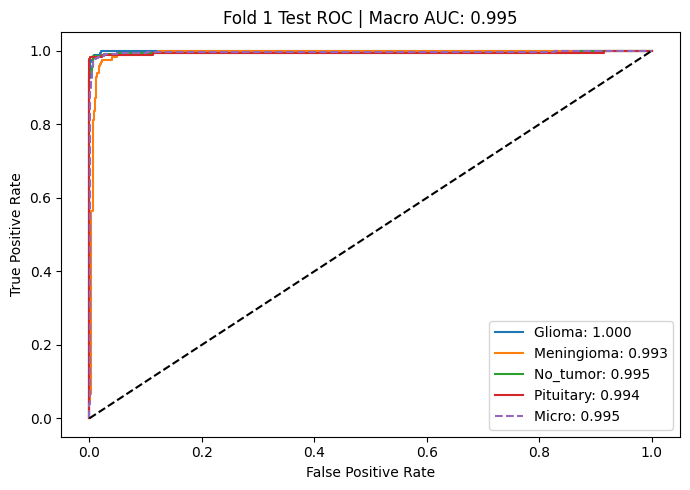


Metrics
Accuracy     0.974395
Precision    0.974764
Recall       0.974395
F1           0.974507
MCC          0.965829
Kappa        0.965782
LogLoss      0.126000
Macro_AUC    0.995413
Micro_AUC    0.995399
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          2           5
1  Meningioma         11           6
2    No_tumor          3           4
3   Pituitary          2           3


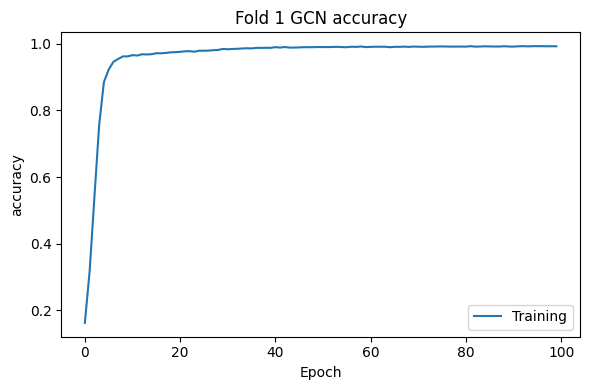

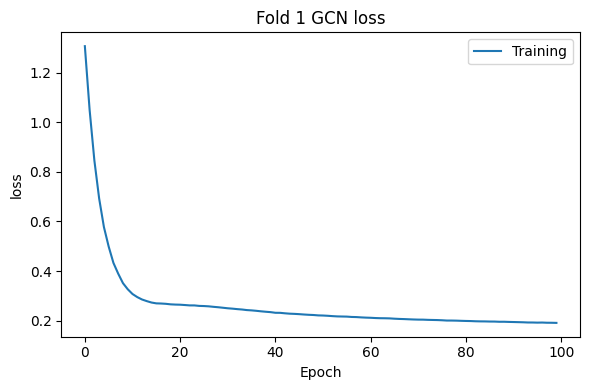


Graph Statistics
 {'Nodes': 7023, 'Edges': 53078, 'Average_Degree': 15.115477716075752, 'Min_Degree': 12, 'Max_Degree': 44, 'Density': 0.002152588680728532, 'Components': 2, 'Largest_Component': 6997}

Fold 2 Test
              precision    recall  f1-score     support
Glioma         0.963636  0.981481  0.972477  162.000000
Meningioma     0.938650  0.927273  0.932927  165.000000
No_tumor       0.975000  0.975000  0.975000  200.000000
Pituitary      0.982857  0.977273  0.980057  176.000000
accuracy       0.965861  0.965861  0.965861    0.965861
macro avg      0.965036  0.965257  0.965115  703.000000
weighted avg   0.965817  0.965861  0.965810  703.000000

Confusion Matrix
[[159   2   0   1]
 [  6 153   5   1]
 [  0   4 195   1]
 [  0   4   0 172]]


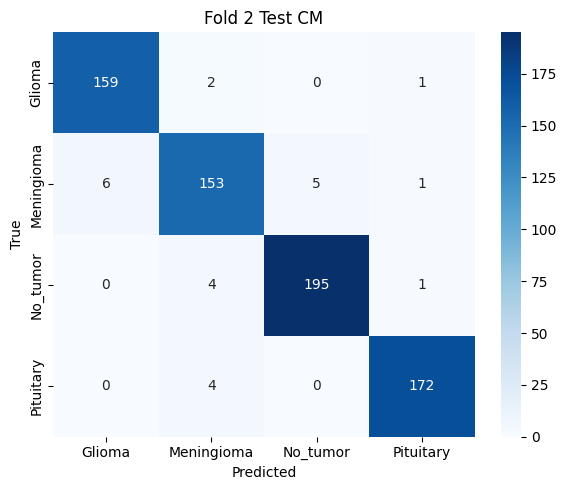

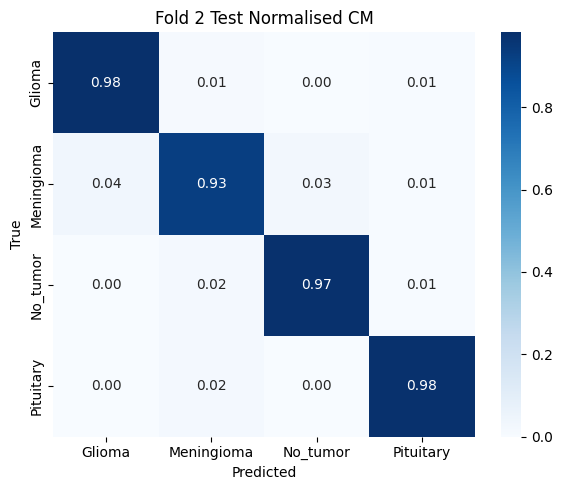

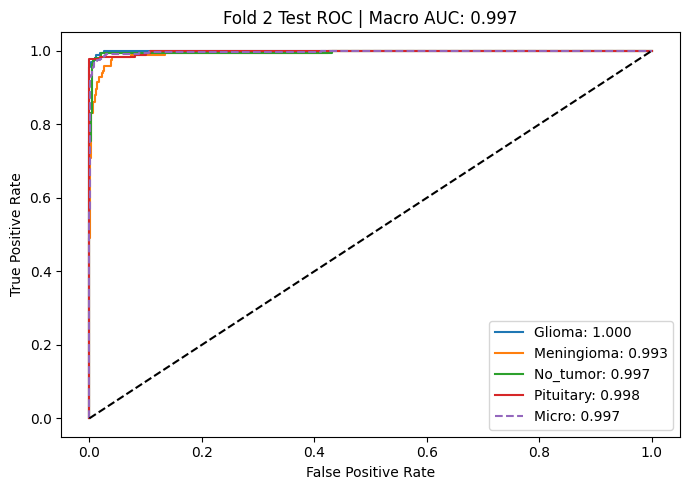


Metrics
Accuracy     0.965861
Precision    0.965817
Recall       0.965861
F1           0.965810
MCC          0.954391
Kappa        0.954373
LogLoss      0.130239
Macro_AUC    0.996789
Micro_AUC    0.997039
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          6           3
1  Meningioma         10          12
2    No_tumor          5           5
3   Pituitary          3           4


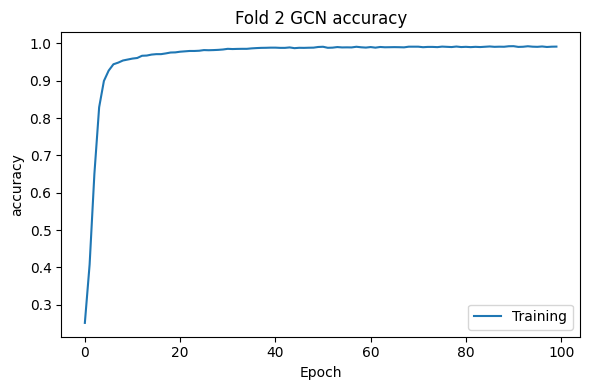

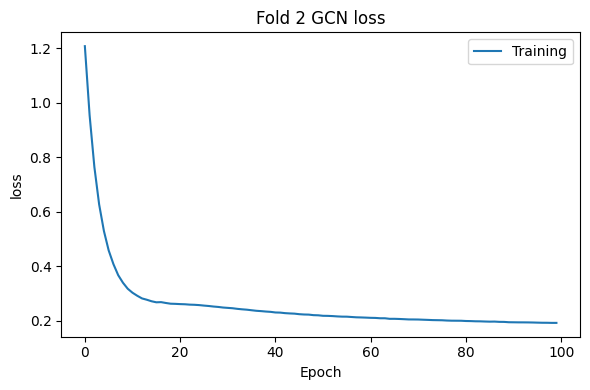


Graph Statistics
 {'Nodes': 7023, 'Edges': 52959, 'Average_Degree': 15.08158906450235, 'Min_Degree': 12, 'Max_Degree': 38, 'Density': 0.00214776261243269, 'Components': 1, 'Largest_Component': 7023}

Fold 3 Test
              precision    recall  f1-score     support
Glioma         0.981366  0.975309  0.978328  162.000000
Meningioma     0.940476  0.957576  0.948949  165.000000
No_tumor       0.984925  0.980000  0.982456  200.000000
Pituitary      0.982857  0.977273  0.980057  176.000000
accuracy       0.972973  0.972973  0.972973    0.972973
macro avg      0.972406  0.972539  0.972448  703.000000
weighted avg   0.973155  0.972973  0.973040  703.000000

Confusion Matrix
[[158   4   0   0]
 [  1 158   3   3]
 [  1   3 196   0]
 [  1   3   0 172]]


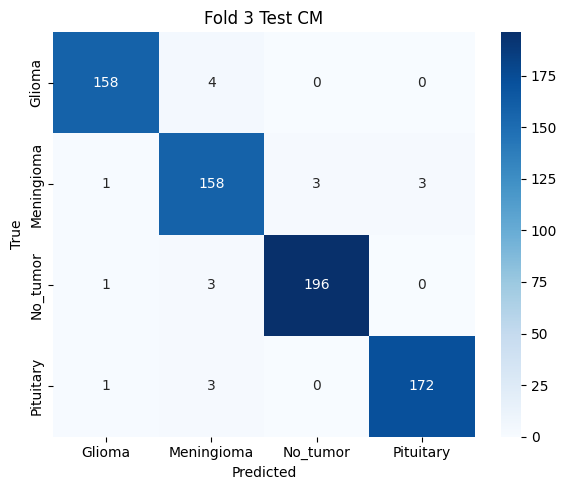

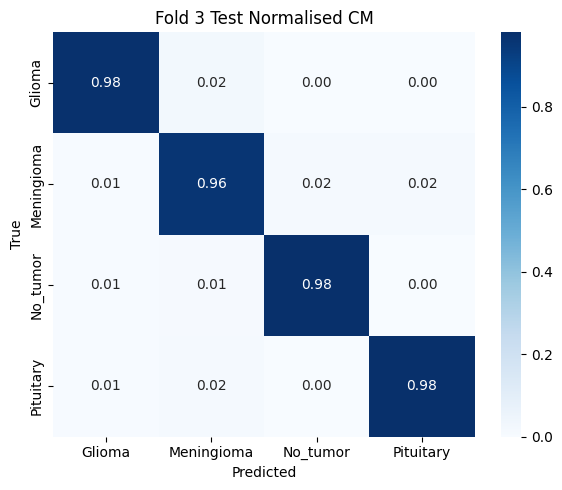

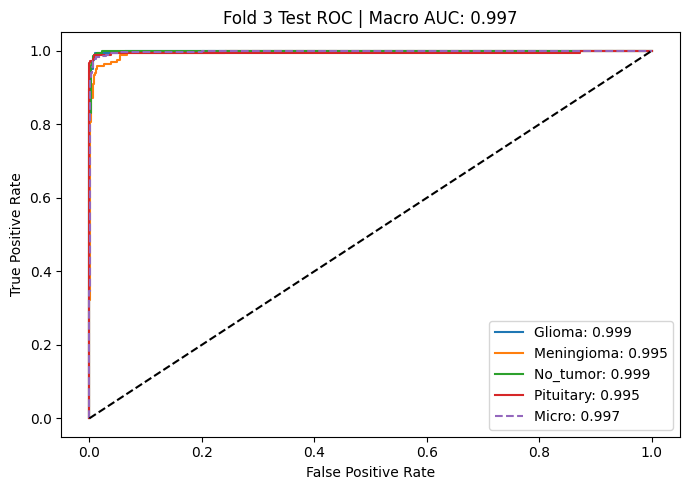


Metrics
Accuracy     0.972973
Precision    0.973155
Recall       0.972973
F1           0.973040
MCC          0.963897
Kappa        0.963881
LogLoss      0.122053
Macro_AUC    0.997064
Micro_AUC    0.997212
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          3           4
1  Meningioma         10           7
2    No_tumor          3           4
3   Pituitary          3           4


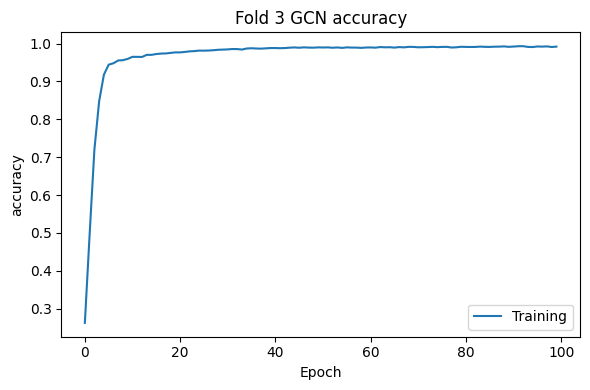

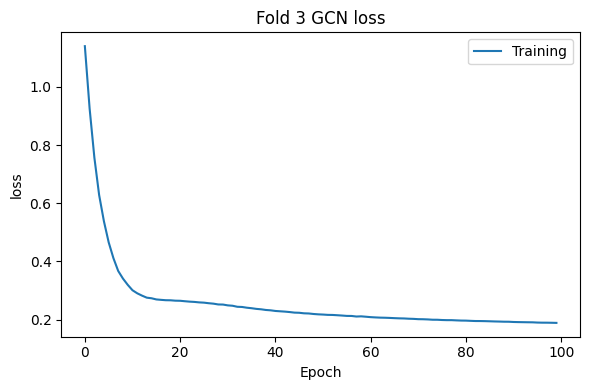


Graph Statistics
 {'Nodes': 7023, 'Edges': 53117, 'Average_Degree': 15.126584080877118, 'Min_Degree': 12, 'Max_Degree': 39, 'Density': 0.0021541703333633035, 'Components': 1, 'Largest_Component': 7023}

Fold 4 Test
              precision    recall  f1-score     support
Glioma         0.957576  0.975309  0.966361  162.000000
Meningioma     0.956522  0.933333  0.944785  165.000000
No_tumor       0.980000  0.980000  0.980000  200.000000
Pituitary      0.983051  0.988636  0.985836  176.000000
accuracy       0.970128  0.970128  0.970128    0.970128
macro avg      0.969287  0.969320  0.969245  703.000000
weighted avg   0.970086  0.970128  0.970053  703.000000

Confusion Matrix
[[158   4   0   0]
 [  5 154   3   3]
 [  2   2 196   0]
 [  0   1   1 174]]


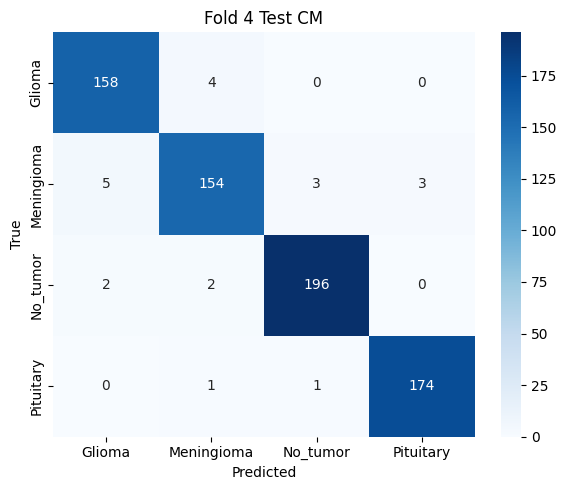

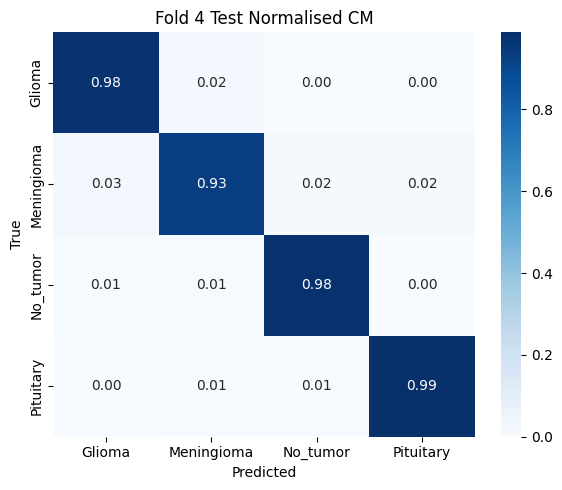

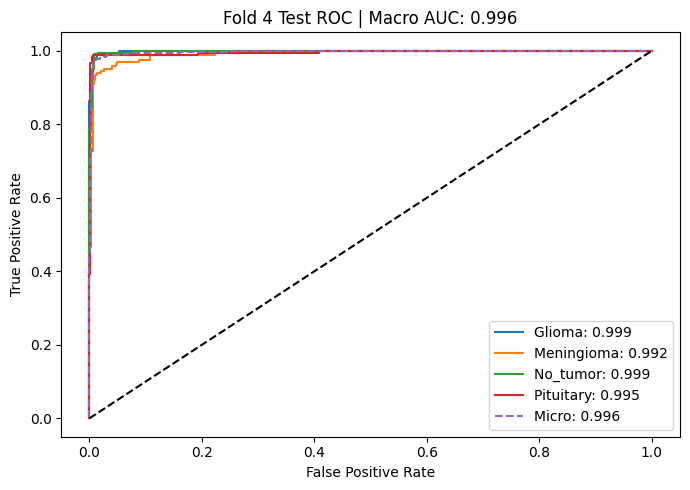


Metrics
Accuracy     0.970128
Precision    0.970086
Recall       0.970128
F1           0.970053
MCC          0.960108
Kappa        0.960074
LogLoss      0.131081
Macro_AUC    0.996171
Micro_AUC    0.996475
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          7           4
1  Meningioma          7          11
2    No_tumor          4           4
3   Pituitary          3           2


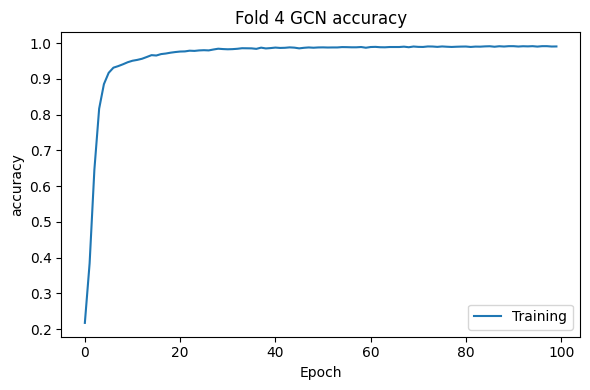

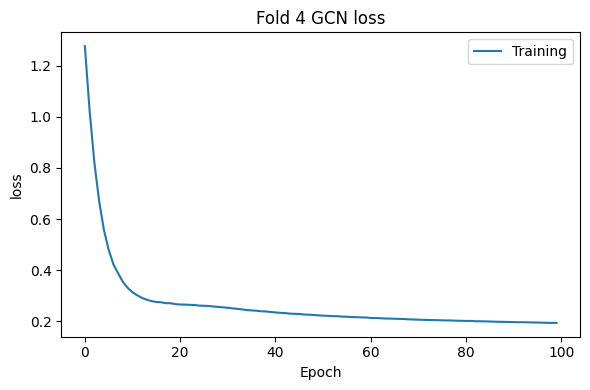


Graph Statistics
 {'Nodes': 7023, 'Edges': 53221, 'Average_Degree': 15.156201053680764, 'Min_Degree': 12, 'Max_Degree': 42, 'Density': 0.002158388073722695, 'Components': 2, 'Largest_Component': 6979}

Fold 5 Test
              precision    recall  f1-score     support
Glioma         0.987342  0.962963  0.975000  162.000000
Meningioma     0.946108  0.957576  0.951807  165.000000
No_tumor       0.975369  0.990000  0.982630  200.000000
Pituitary      0.994286  0.988636  0.991453  176.000000
accuracy       0.975818  0.975818  0.975818    0.975818
macro avg      0.975776  0.974794  0.975223  703.000000
weighted avg   0.975996  0.975818  0.975846  703.000000

Confusion Matrix
[[156   6   0   0]
 [  2 158   5   0]
 [  0   1 198   1]
 [  0   2   0 174]]


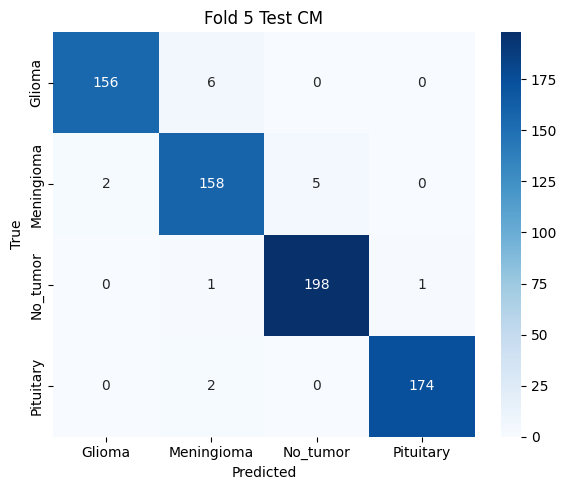

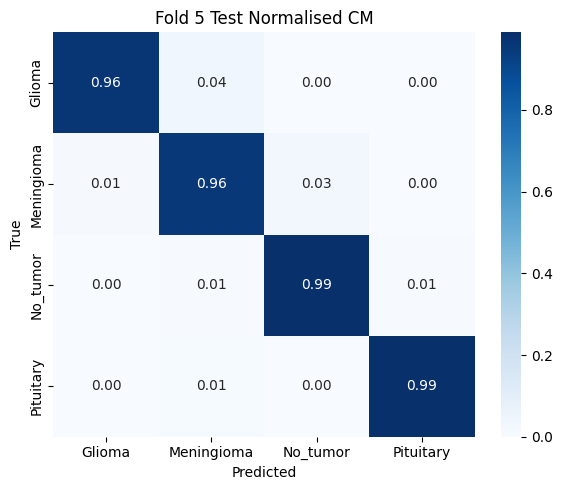

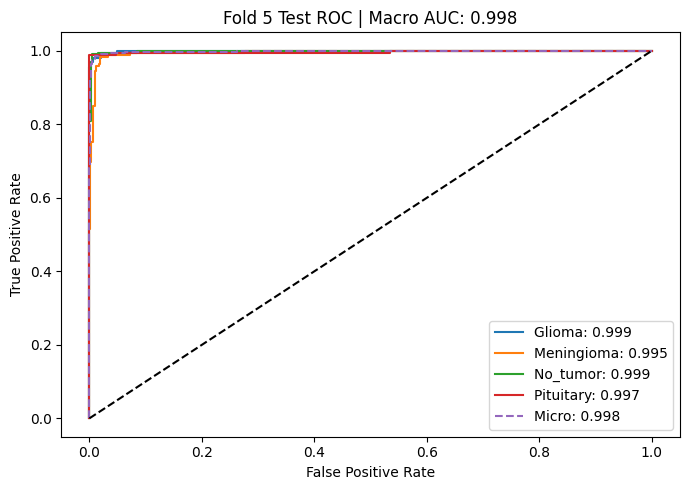


Metrics
Accuracy     0.975818
Precision    0.975996
Recall       0.975818
F1           0.975846
MCC          0.967709
Kappa        0.967670
LogLoss      0.111611
Macro_AUC    0.997561
Micro_AUC    0.997758
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          2           6
1  Meningioma          9           7
2    No_tumor          5           2
3   Pituitary          1           2


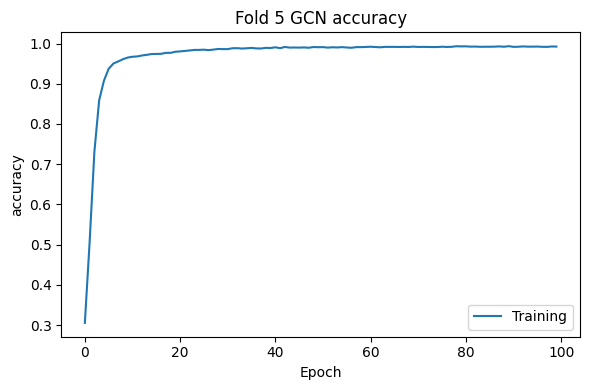

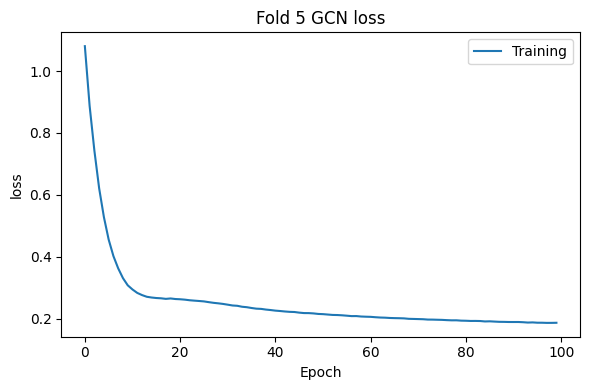


Graph Statistics
 {'Nodes': 7023, 'Edges': 53072, 'Average_Degree': 15.113769044567848, 'Min_Degree': 12, 'Max_Degree': 34, 'Density': 0.0021523453495539517, 'Components': 1, 'Largest_Component': 7023}

Hybrid-GCN-kNN Combined
              precision    recall  f1-score      support
Glioma         0.975248  0.972840  0.974042   810.000000
Meningioma     0.943305  0.947879  0.945586   825.000000
No_tumor       0.980020  0.981000  0.980510  1000.000000
Pituitary      0.986317  0.982955  0.984633   880.000000
accuracy       0.971835  0.971835  0.971835     0.971835
macro avg      0.971222  0.971168  0.971193  3515.000000
weighted avg   0.971879  0.971835  0.971855  3515.000000

Confusion Matrix
[[788  21   0   1]
 [ 16 782  19   8]
 [  3  13 981   3]
 [  1  13   1 865]]


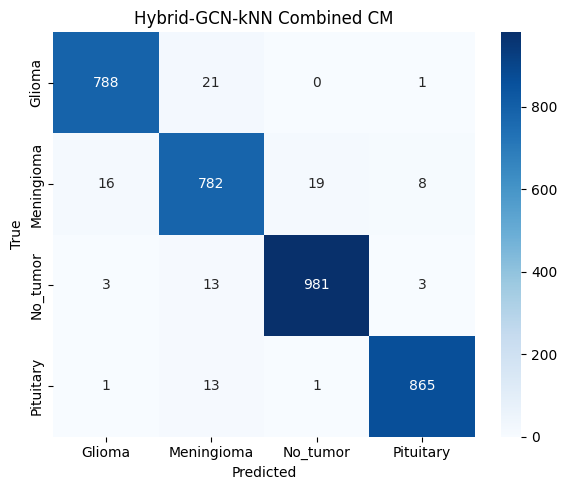

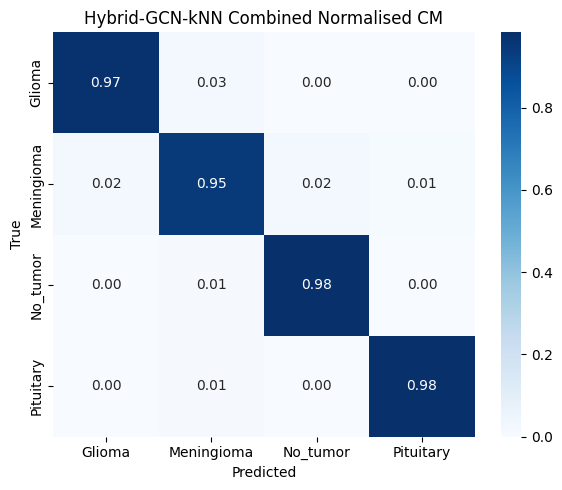

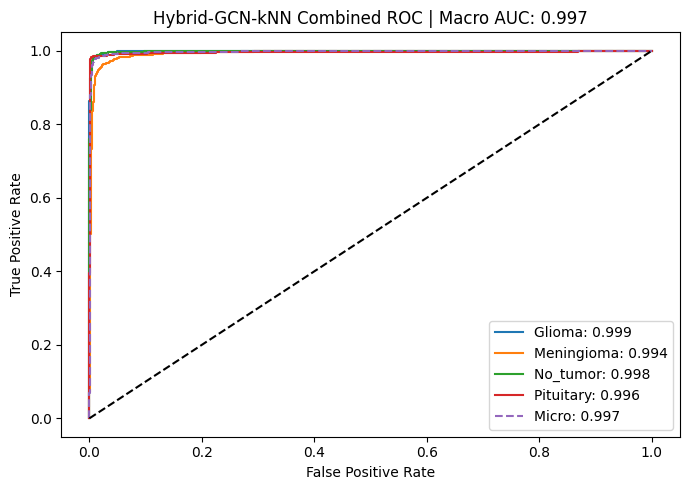


Metrics
Accuracy     0.971835
Precision    0.971879
Recall       0.971835
F1           0.971855
MCC          0.962357
Kappa        0.962356
LogLoss      0.124197
Macro_AUC    0.996606
Micro_AUC    0.996768
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma         20          22
1  Meningioma         47          43
2    No_tumor         20          19
3   Pituitary         12          15

5-FOLD RESULTS
Scores: [0.97439545 0.9658606  0.97297297 0.97012802 0.97581792]
Mean: 0.9718349928876243
SD: 0.0035304903687029465
95% CI: (0.9669338865360577, 0.9767360992391909)

TIME
CNN: 18.91468460957209 min
GCN: 0.11289305130640666 min
Total: 19.0275776608785 min

COMPUTATIONAL METRICS
         Model  Parameters  Model_Size_MB  Nodes  Edges  Average_Degree  Density  Components  Largest_Component  GCN_FLOPs  GCN_GFLOPs  Inference_Time_sec  Latency_ms  Throughput_nodes_sec   RAM_GB
Hybrid-GCN-kNN       17156       0.065445   7023  53072       15.113769 0.002152     

In [2]:
import os, glob, gc, time, psutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, roc_curve, auc
)

from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter


# ============================================================
# CONFIG
# ============================================================

SEED=123
DATA_DIR=r"D:/GCN/Brain_Tumor/four_class"

IMG_SIZE=(150,150)
DOMAIN_SIZE=(64,64)

BATCH_SIZE=32
K_FOLDS=5
K_NEIGHBORS=12

LR_CNN=1e-3
LR_GCN=0.005

EPOCHS_CNN=50
EPOCHS_GCN=100

DROPOUT=0.3
AUGMENT=True

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# DATA
# ============================================================
class_names=sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
class_to_idx={c:i for i,c in enumerate(class_names)}

paths,labels=[],[]
for c in class_names:
    for f in glob.glob(os.path.join(DATA_DIR,c,"*")):
        if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
            paths.append(f); labels.append(class_to_idx[c])

paths=np.asarray(paths); labels=np.asarray(labels,dtype=np.int32)
N=len(paths); NUM_CLASSES=len(class_names); all_indices=np.arange(N)

dev_indices,test_indices=train_test_split(all_indices,test_size=0.10,stratify=labels,random_state=SEED)
skf=StratifiedKFold(n_splits=K_FOLDS,shuffle=True,random_state=SEED)

print("Total:",N); print("Classes:",class_names); print("Distribution:",np.unique(labels,return_counts=True))
print("Development:",len(dev_indices)); print("Test:",len(test_indices))

# ============================================================
# IMAGE PIPELINE
# ============================================================
def load_img(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32)
    img=tf.image.resize(img,IMG_SIZE); img.set_shape([*IMG_SIZE,3])
    return img,label

def augment_img(img,label):
    if AUGMENT:
        img=tf.image.random_flip_left_right(img)
        img=tf.image.rot90(img,tf.random.uniform([],0,4,dtype=tf.int32))
    return img,label

def make_dataset(indices,training=False,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((paths[indices],labels[indices]))
    if shuffle: ds=ds.shuffle(len(indices),seed=SEED)
    ds=ds.map(load_img,num_parallel_calls=tf.data.AUTOTUNE)
    if training: ds=ds.map(augment_img,num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# gCNN-4
# ============================================================

def build_gcnn4():
    inp=Input(shape=(*IMG_SIZE,3))
    x=layers.Conv2D(32,3,padding="same",activation="relu")(inp); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(64,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(128,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(256,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.GlobalAveragePooling2D()(x)
    feature=layers.Dense(512,activation="relu",name="deep_feature")(x)
    output=layers.Dense(NUM_CLASSES,activation="softmax")(feature)
    return Model(inp,output,name="gCNN4"),Model(inp,feature,name="gCNN4_backbone")

def extract_deep_features(backbone,dataset):
    X,Y=[],[]
    for xb,yb in dataset:
        X.append(backbone(xb,training=False).numpy()); Y.append(yb.numpy())
    return np.vstack(X).astype(np.float32),np.concatenate(Y)


# ============================================================
# RAW + DOMAIN FEATURES
# ============================================================

def entropy_feature(gray):
    hist=tf.cast(tf.histogram_fixed_width(gray,[0.,1.],nbins=32),tf.float32)
    prob=hist/tf.reduce_sum(hist); prob=tf.where(prob>0,prob,tf.ones_like(prob))
    return -tf.reduce_sum(prob*tf.math.log(prob))

def extract_raw_domain(path):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32); img=tf.image.resize(img,IMG_SIZE)
    gray=tf.image.rgb_to_grayscale(img); raw=tf.reshape(gray,[-1]); small=tf.image.resize(gray,DOMAIN_SIZE)

    mean=tf.reduce_mean(small); std=tf.math.reduce_std(small); variance=tf.math.reduce_variance(small)
    minimum=tf.reduce_min(small); maximum=tf.reduce_max(small)

    sobel=tf.image.sobel_edges(tf.expand_dims(small,0))
    gradient=tf.sqrt(tf.reduce_sum(tf.square(sobel),axis=-1))
    edge=tf.reduce_mean(gradient); entropy=entropy_feature(small)

    domain=tf.stack([mean,std,variance,minimum,maximum,edge,entropy])
    return raw,tf.cast(domain,tf.float32)

def extract_raw_domain_features():
    raw,domain=[],[]; start=time.time()
    for i,p in enumerate(paths):
        r,d=extract_raw_domain(p); raw.append(r.numpy()); domain.append(d.numpy())
        if i%500==0: print("Processed:",i)
    print("Raw/domain extraction:",round((time.time()-start)/60,2),"min")
    return np.asarray(raw,dtype=np.float32),np.asarray(domain,dtype=np.float32)


# ============================================================
# FOLD-SPECIFIC FEATURE FUSION
# ============================================================

def fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_idx):

    def pca_branch(X):
        n=min(128,X.shape[1],len(train_idx)-1)
        pca=PCA(n_components=n,random_state=SEED); scaler=StandardScaler()
        tr=pca.fit_transform(X[train_idx]); va=pca.transform(X[val_idx]); te=pca.transform(X[test_idx])
        tr=scaler.fit_transform(tr); va=scaler.transform(va); te=scaler.transform(te)
        return tr,va,te

    deep_tr,deep_va,deep_te=pca_branch(X_deep)
    raw_tr,raw_va,raw_te=pca_branch(X_raw)

    scaler=StandardScaler()
    domain_tr=scaler.fit_transform(X_domain[train_idx])
    domain_va=scaler.transform(X_domain[val_idx]); domain_te=scaler.transform(X_domain[test_idx])

    X_train=np.concatenate([deep_tr,raw_tr,domain_tr],axis=1)
    X_val=np.concatenate([deep_va,raw_va,domain_va],axis=1)
    X_test=np.concatenate([deep_te,raw_te,domain_te],axis=1)

    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train); X_val=scaler.transform(X_val); X_test=scaler.transform(X_test)

    return X_train.astype(np.float32),X_val.astype(np.float32),X_test.astype(np.float32)
# ============================================================
# kNN COSINE GRAPH
# UNCHANGED
# ============================================================

def build_knn_cosine_graph(X,k=K_NEIGHBORS):

    n=len(X)
    k=min(k,n-1)

    knn=NearestNeighbors(
        n_neighbors=k+1,
        metric="cosine"
    ).fit(X)

    dist,idx=knn.kneighbors(X)

    rows,cols,vals=[],[],[]

    for i in range(n):

        for j,d in zip(idx[i],dist[i]):

            if i!=j:

                w=1-float(d)

                if w>0:
                    rows.append(i)
                    cols.append(j)
                    vals.append(w)

    A=coo_matrix(
        (vals,(rows,cols)),
        shape=(n,n),
        dtype=np.float32
    ).tocsr()

    A=A.maximum(A.T)
    A.setdiag(1.0)
    A.eliminate_zeros()

    return A


# ============================================================
# GRAPH HELPERS
# ============================================================
def sparse_adj(A):
    A=A.tocoo()
    S=tf.SparseTensor(indices=np.column_stack((A.row,A.col)).astype(np.int64),values=A.data.astype(np.float32),dense_shape=A.shape)
    return tf.sparse.reorder(S)

def graph_stats(A):
    A=A.copy().tocsr(); N=A.shape[0]; A.setdiag(0); A.eliminate_zeros()
    edges=A.nnz//2; degree=np.asarray((A>0).sum(axis=1)).ravel()
    components,cc=connected_components(A,directed=False,return_labels=True); sizes=np.bincount(cc)
    return {"Nodes":N,"Edges":edges,"Average_Degree":degree.mean(),"Min_Degree":degree.min(),"Max_Degree":degree.max(),
            "Density":2*edges/(N*(N-1)) if N>1 else 0,"Components":components,"Largest_Component":sizes.max()}


# ============================================================
# GCN
# ============================================================

def build_gcn(feature_dim,num_nodes):
    X_in=Input(shape=(feature_dim,),name="features"); A_in=Input(shape=(num_nodes,num_nodes),sparse=True,name="graph")
    x=GCNConv(64,activation="relu",kernel_regularizer=regularizers.l2(5e-4))([X_in,A_in]); x=layers.Dropout(DROPOUT)(x)
    out=GCNConv(NUM_CLASSES,activation="softmax")([x,A_in]); model=Model([X_in,A_in],out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_GCN),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),weighted_metrics=["accuracy"])
    return model
# ============================================================
# PLOTS + EVALUATION
# ============================================================
def plot_cm(cm,title,normalised=False):
    if normalised: cm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
    plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt=".2f" if normalised else "d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

def plot_roc(y_true,prob,title):
    y_bin=label_binarize(y_true,classes=np.arange(NUM_CLASSES)); plt.figure(figsize=(7,5)); aucs=[]
    for i in range(NUM_CLASSES):
        fpr,tpr,_=roc_curve(y_bin[:,i],prob[:,i]); a=auc(fpr,tpr); aucs.append(a); plt.plot(fpr,tpr,label=f"{class_names[i]}: {a:.3f}")
    fpr,tpr,_=roc_curve(y_bin.ravel(),prob.ravel()); micro=auc(fpr,tpr)
    plt.plot(fpr,tpr,"--",label=f"Micro: {micro:.3f}"); plt.plot([0,1],[0,1],"k--")
    plt.title(f"{title} | Macro AUC: {np.mean(aucs):.3f}"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend(); plt.tight_layout(); plt.show()
    return np.mean(aucs),micro

def plot_history(history,title):
    for metric in ["accuracy","loss"]:
        if metric not in history: continue
        plt.figure(figsize=(6,4)); plt.plot(history[metric],label="Training"); val_key="val_"+metric
        if val_key in history: plt.plot(history[val_key],label="Validation")
        plt.title(f"{title} {metric}"); plt.xlabel("Epoch"); plt.ylabel(metric); plt.legend(); plt.tight_layout(); plt.show()

def evaluate_results(y_true,y_pred,prob,title):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); prob=np.asarray(prob)
    print("\n"+"="*70); print(title); print("="*70)
    report=pd.DataFrame(classification_report(y_true,y_pred,target_names=class_names,output_dict=True,zero_division=0)).T; print(report)
    cm=confusion_matrix(y_true,y_pred); print("\nConfusion Matrix"); print(cm)
    plot_cm(cm,title+" CM"); plot_cm(cm,title+" Normalised CM",True); macro_auc,micro_auc=plot_roc(y_true,prob,title+" ROC")

    metrics={"Accuracy":accuracy_score(y_true,y_pred),"Precision":precision_score(y_true,y_pred,average="weighted",zero_division=0),
             "Recall":recall_score(y_true,y_pred,average="weighted",zero_division=0),"F1":f1_score(y_true,y_pred,average="weighted",zero_division=0),
             "MCC":matthews_corrcoef(y_true,y_pred),"Kappa":cohen_kappa_score(y_true,y_pred),
             "LogLoss":log_loss(y_true,prob,labels=np.arange(NUM_CLASSES)),"Macro_AUC":macro_auc,"Micro_AUC":micro_auc}

    print("\nMetrics"); print(pd.Series(metrics))
    FP=cm.sum(axis=0)-np.diag(cm); FN=cm.sum(axis=1)-np.diag(cm)
    print("\nError Analysis"); print(pd.DataFrame({"Class":class_names,"Type_I_FP":FP,"Type_II_FN":FN}))
    return report,metrics


# ============================================================
# FEATURE EXTRACTION
# ============================================================

print("\nExtracting raw/domain features"); X_raw,X_domain=extract_raw_domain_features()

# ============================================================
# 5-FOLD TRANSDUCTIVE TRAINING
# ============================================================
# ============================================================
# 5-FOLD TRANSDUCTIVE TRAINING
# ============================================================

fold_results=[]
final_model=None
final_X=None
final_A=None
final_graph_raw=None

for fold,(tr,val) in enumerate(skf.split(dev_indices,labels[dev_indices]),1):

    print(f"\n{'='*70}")
    print(f"FOLD {fold}")
    print("="*70)

    train_idx=dev_indices[tr]
    val_idx=dev_indices[val]

    tf.keras.backend.clear_session()
    gc.collect()

    train_ds=make_dataset(train_idx,training=True,shuffle=True)
    val_ds=make_dataset(val_idx)

    cnn,backbone=build_gcnn4()

    cnn.compile(optimizer=tf.keras.optimizers.Adam(LR_CNN),
                loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    start=time.time()
    cnn_hist=cnn.fit(train_ds,validation_data=val_ds,epochs=EPOCHS_CNN,
                     callbacks=[EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)],
                     verbose=1)
    cnn_time=time.time()-start

    X_deep,_=extract_deep_features(backbone,make_dataset(np.arange(N)))

    del cnn,backbone,train_ds,val_ds
    gc.collect()

    X_train,X_val,X_test=fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_indices)

    X_all=np.vstack([X_train,X_val,X_test])
    y_all=np.concatenate([labels[train_idx],labels[val_idx],labels[test_indices]])

    # kNN unchanged
    A_graph=build_knn_cosine_graph(X_all)
    A_norm=csr_matrix(gcn_filter(A_graph),dtype=np.float32)
    A=sparse_adj(A_norm)

    Y=to_categorical(y_all,NUM_CLASSES)

    mask=np.zeros(len(y_all),dtype=np.float32)
    mask[:len(train_idx)]=1.0

    gcn=build_gcn(X_all.shape[1],len(X_all))

    start=time.time()
    hist=gcn.fit([X_all,A],Y,sample_weight=mask,epochs=EPOCHS_GCN,
                 batch_size=len(X_all),shuffle=False,
                 callbacks=[EarlyStopping(monitor="loss",patience=30,restore_best_weights=True)],
                 verbose=1)
    gcn_time=time.time()-start

    prob=gcn([X_all,A],training=False).numpy()
    pred=np.argmax(prob,axis=1)

    test_start=len(train_idx)+len(val_idx)
    yt=y_all[test_start:]
    yp=pred[test_start:]
    pr=prob[test_start:]

    acc=accuracy_score(yt,yp)

    fold_results.append({
        "fold":fold,"true":yt,"pred":yp,"prob":pr,"accuracy":acc,
        "history":hist.history,"graph":graph_stats(A_graph),
        "cnn_time":cnn_time,"gcn_time":gcn_time
    })

    print(f"\nFold {fold} Test Accuracy: {acc:.4f}")

    final_model=gcn
    final_X=X_all
    final_A=A
    final_graph_raw=A_graph

    gc.collect()

print("\nTRAINING COMPLETED")


# ============================================================
# EACH FOLD
# ============================================================

for item in fold_results:

    evaluate_results(item["true"],item["pred"],item["prob"],f"Fold {item['fold']} Test")
    plot_history(item["history"],f"Fold {item['fold']} GCN")
    print("\nGraph Statistics\n",item["graph"])


# ============================================================
# COMBINED 5-FOLD TEST RESULTS
# ============================================================

y_true=np.concatenate([x["true"] for x in fold_results])
y_pred=np.concatenate([x["pred"] for x in fold_results])
prob=np.vstack([x["prob"] for x in fold_results])

final_report,final_metrics=evaluate_results(y_true,y_pred,prob,"Hybrid-GCN-kNN Combined")


# ============================================================
# FOLD STATISTICS
# ============================================================

scores=np.asarray([x["accuracy"] for x in fold_results])

ci=stats.t.interval(0.95,len(scores)-1,loc=scores.mean(),scale=stats.sem(scores))

print("\n5-FOLD RESULTS")
print("Scores:",scores)
print("Mean:",scores.mean())
print("SD:",scores.std())
print("95% CI:",ci)


# ============================================================
# COMPUTATION TIME
# ============================================================

cnn_times=np.asarray([x["cnn_time"] for x in fold_results])
gcn_times=np.asarray([x["gcn_time"] for x in fold_results])

print("\nTIME")
print("CNN:",cnn_times.mean()/60,"min")
print("GCN:",gcn_times.mean()/60,"min")
print("Total:",(cnn_times.mean()+gcn_times.mean())/60,"min")


# ============================================================
# COMPUTATIONAL METRICS
# ============================================================

params=final_model.count_params()
model_size=params*4/(1024**2)

graph_info=graph_stats(final_graph_raw)
edges=graph_info["Edges"]
F=final_X.shape[1]

gcn_flops=2*edges*F*64+2*edges*64*NUM_CLASSES

start=time.time()
_=final_model([final_X,final_A],training=False)
inference_time=max(time.time()-start,1e-9)

nodes=len(final_X)

computational=pd.DataFrame([{
    "Model":"Hybrid-GCN-kNN",
    "Parameters":params,
    "Model_Size_MB":model_size,
    "Nodes":graph_info["Nodes"],
    "Edges":graph_info["Edges"],
    "Average_Degree":graph_info["Average_Degree"],
    "Density":graph_info["Density"],
    "Components":graph_info["Components"],
    "Largest_Component":graph_info["Largest_Component"],
    "GCN_FLOPs":gcn_flops,
    "GCN_GFLOPs":gcn_flops/1e9,
    "Inference_Time_sec":inference_time,
    "Latency_ms":1000*inference_time/nodes,
    "Throughput_nodes_sec":nodes/inference_time,
    "RAM_GB":psutil.Process(os.getpid()).memory_info().rss/1024**3
}])

print("\nCOMPUTATIONAL METRICS")
print(computational.to_string(index=False))


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n"+"="*70)
print("EXPERIMENT 1 - HYBRID GCN kNN")
print("="*70)
print("CNN                 : gCNN-4")
print("Deep features       : 512")
print("Raw features        : Grayscale pixels")
print("Domain features     : 7")
print("PCA                 : Max 128 per deep/raw branch")
print("k                   :",K_NEIGHBORS)
print("Metric              : Cosine distance")
print("Weight              : 1 - cosine distance")
print("Symmetrization      : A = max(A, A.T)")
print("Self loops          : Yes")
print("GCN normalization   : gcn_filter")
print("GCN hidden units    : 64")
print("Dropout             :",DROPOUT)
print("GCN LR              :",LR_GCN)
print("Label smoothing     : 0.05")
print("Mode                : Transductive only")
print("Seed                :",SEED)
print("="*70)

In [1]:
# ============================================================
# COMPLETE MEMORY / CACHE / VARIABLE CLEANUP
# ============================================================

import os, gc, time, psutil
def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 28.72 MB
Variable count  : 13
Variables       : clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, delete_model_variables, force_garbage_collection, gc, get_ram_usage, get_user_variables, open, os, print_variable_information, psutil, time

[1] Closing Matplotlib figures...
    Matplotlib figures closed.

[2] Clearing TensorFlow / Keras...
    Keras session cleared.
    GPU:0 current: 0.00 MB
    GPU:0 peak   : 0.00 MB
    TensorFlow cleanup completed.

[3] Running garbage collection...
    Garbage-collected objects: 0

[4] Deleting user/model/data variables...
    Variables selected for deletion: 1
    Deleting: open
    Successfully deleted: 1

[5] Final garbage collection...
    Garbage-collected objects: 0

AFTER CLEANING
----------------------------------------------------------------------
RAM usage       : 838.

Total: 7023
Classes: ['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']
Distribution: (array([0, 1, 2, 3]), array([1621, 1645, 2000, 1757], dtype=int64))
Development: 6320
Test: 703

Extracting raw/domain features
Processed: 0
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
Processed: 5500
Processed: 6000
Processed: 6500
Processed: 7000
Raw/domain extraction: 1.47 min

FOLD 1
Epoch 1/50
158/158 [==============================] - 11s 48ms/step - loss: 1.0708 - accuracy: 0.5026 - val_loss: 0.9025 - val_accuracy: 0.6266
Epoch 2/50
158/158 [==============================] - 7s 46ms/step - loss: 0.7701 - accuracy: 0.6893 - val_loss: 0.7695 - val_accuracy: 0.7263
Epoch 3/50
158/158 [==============================] - 8s 48ms/step - loss: 0.6906 - accuracy: 0.7273 - val_loss: 0.6242 - val_accuracy: 0.7666
Epoch 4/50
158/158 [==============================] - 8s 51ms/step - loss: 0.6096

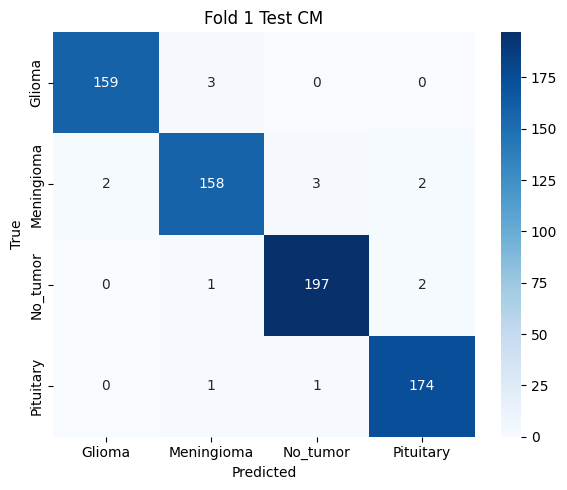

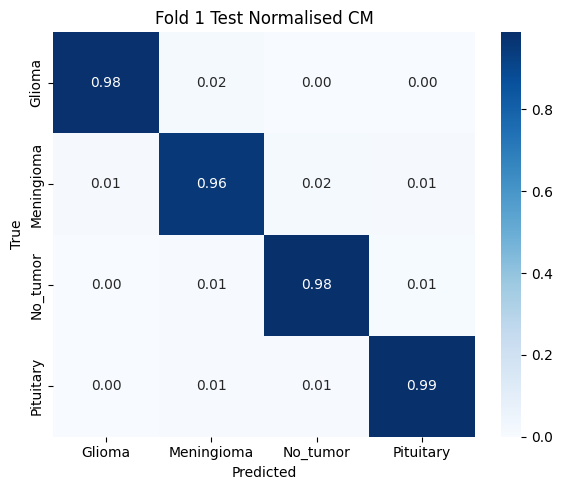

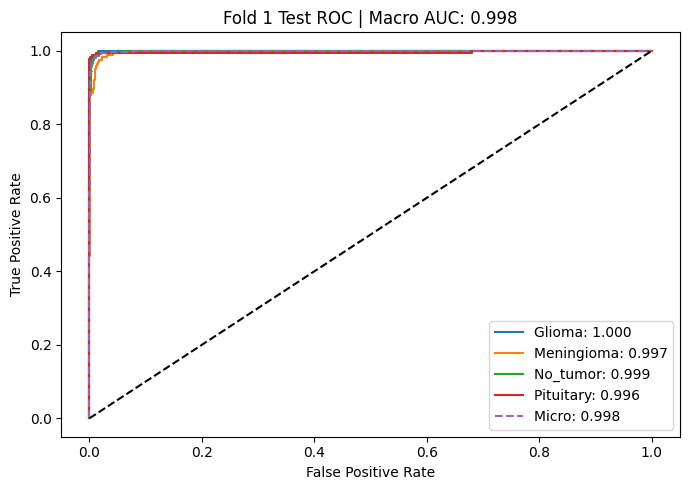


Metrics
Accuracy     0.978663
Precision    0.978650
Recall       0.978663
F1           0.978636
MCC          0.971490
Kappa        0.971477
LogLoss      0.106694
Macro_AUC    0.997998
Micro_AUC    0.998102
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          2           3
1  Meningioma          5           7
2    No_tumor          4           3
3   Pituitary          4           2


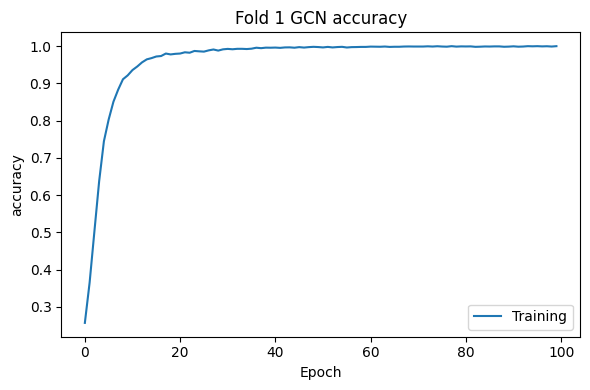

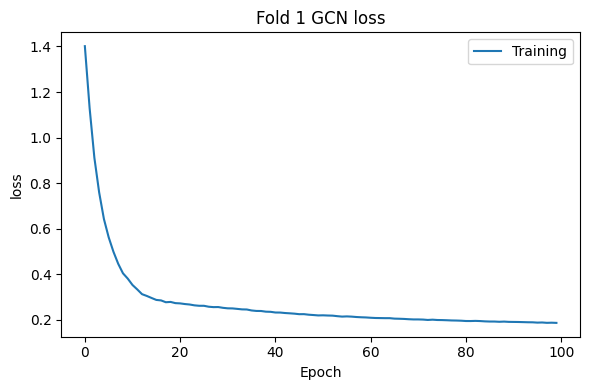


Graph Statistics
 {'Nodes': 7023, 'Edges': 5169, 'Average_Degree': 1.472020504058095, 'Min_Degree': 0, 'Max_Degree': 17, 'Density': 0.00020962980690089644, 'Components': 4165, 'Largest_Component': 18}

Fold 2 Test
              precision    recall  f1-score     support
Glioma         0.975000  0.962963  0.968944  162.000000
Meningioma     0.926380  0.915152  0.920732  165.000000
No_tumor       0.974874  0.970000  0.972431  200.000000
Pituitary      0.955801  0.982955  0.969188  176.000000
accuracy       0.958748  0.958748  0.958748    0.958748
macro avg      0.958014  0.957767  0.957824  703.000000
weighted avg   0.958746  0.958748  0.958681  703.000000

Confusion Matrix
[[156   6   0   0]
 [  2 151   5   7]
 [  1   4 194   1]
 [  1   2   0 173]]


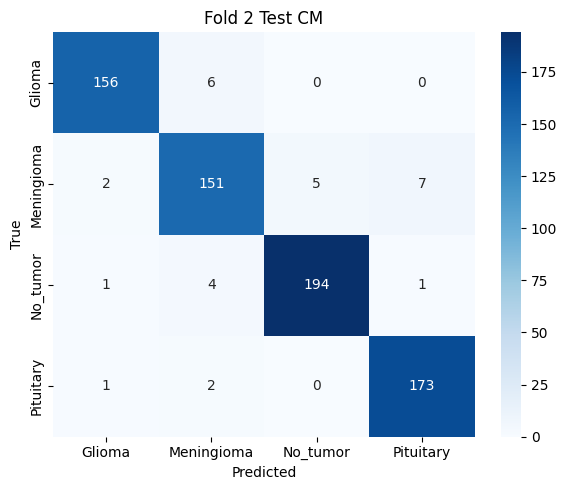

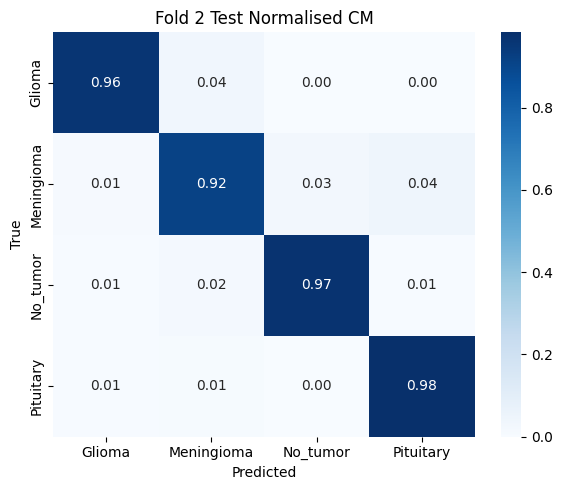

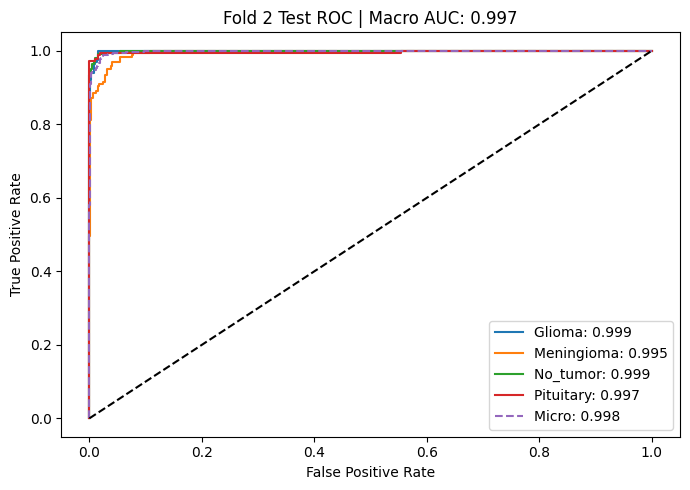


Metrics
Accuracy     0.958748
Precision    0.958746
Recall       0.958748
F1           0.958681
MCC          0.944904
Kappa        0.944861
LogLoss      0.129751
Macro_AUC    0.997358
Micro_AUC    0.997572
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          4           6
1  Meningioma         12          14
2    No_tumor          5           6
3   Pituitary          8           3


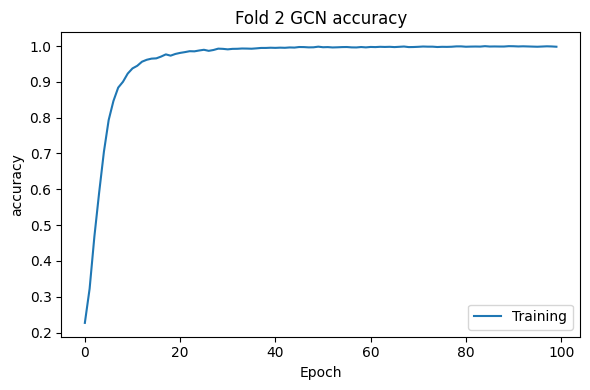

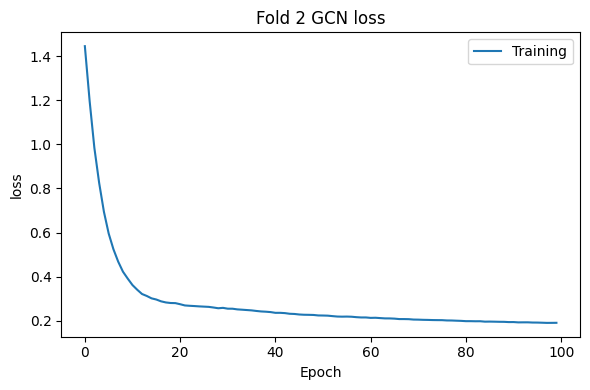


Graph Statistics
 {'Nodes': 7023, 'Edges': 5258, 'Average_Degree': 1.4973657980919834, 'Min_Degree': 0, 'Max_Degree': 17, 'Density': 0.000213239219323837, 'Components': 4170, 'Largest_Component': 21}

Fold 3 Test
              precision    recall  f1-score     support
Glioma         0.981250  0.969136  0.975155  162.000000
Meningioma     0.946108  0.957576  0.951807  165.000000
No_tumor       0.975369  0.990000  0.982630  200.000000
Pituitary      0.994220  0.977273  0.985673  176.000000
accuracy       0.974395  0.974395  0.974395    0.974395
macro avg      0.974237  0.973496  0.973817  703.000000
weighted avg   0.974576  0.974395  0.974435  703.000000

Confusion Matrix
[[157   5   0   0]
 [  2 158   4   1]
 [  0   2 198   0]
 [  1   2   1 172]]


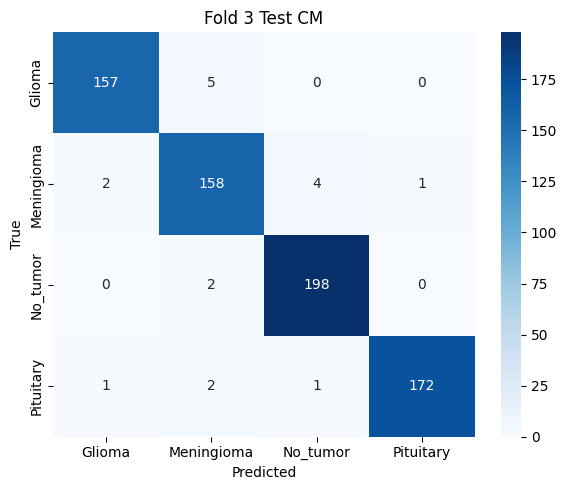

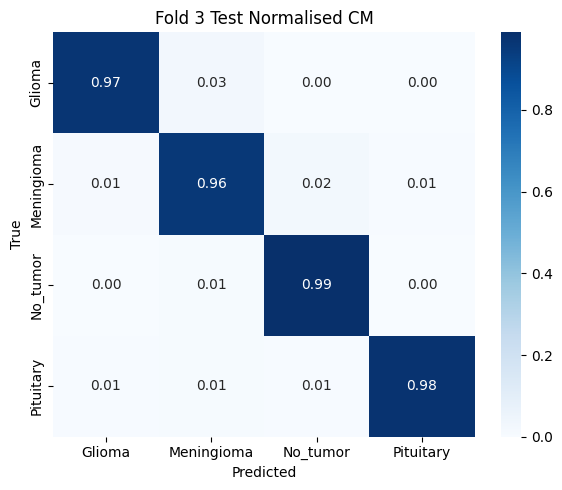

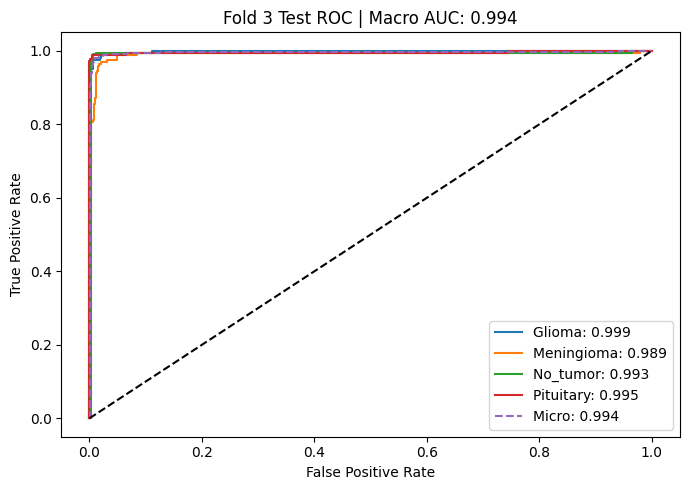


Metrics
Accuracy     0.974395
Precision    0.974576
Recall       0.974395
F1           0.974435
MCC          0.965805
Kappa        0.965771
LogLoss      0.126206
Macro_AUC    0.994094
Micro_AUC    0.994288
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          3           5
1  Meningioma          9           7
2    No_tumor          5           2
3   Pituitary          1           4


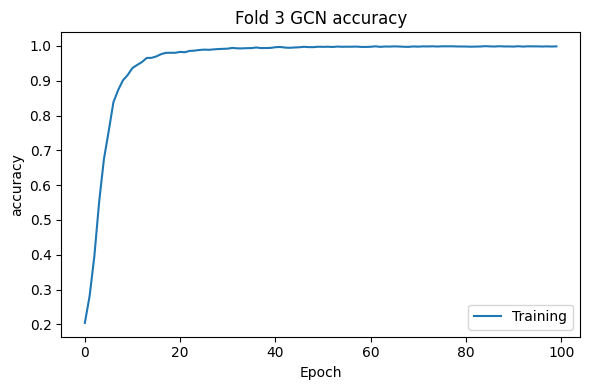

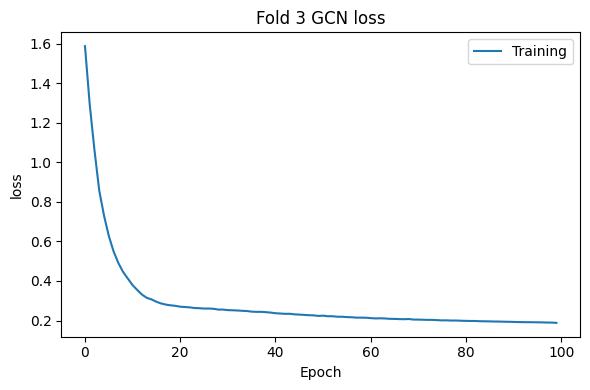


Graph Statistics
 {'Nodes': 7023, 'Edges': 5818, 'Average_Degree': 1.6568418054962266, 'Min_Degree': 0, 'Max_Degree': 17, 'Density': 0.0002359501289513282, 'Components': 3938, 'Largest_Component': 21}

Fold 4 Test
              precision    recall  f1-score     support
Glioma         0.981366  0.975309  0.978328  162.000000
Meningioma     0.950920  0.939394  0.945122  165.000000
No_tumor       0.975248  0.985000  0.980100  200.000000
Pituitary      0.988701  0.994318  0.991501  176.000000
accuracy       0.974395  0.974395  0.974395    0.974395
macro avg      0.974059  0.973505  0.973763  703.000000
weighted avg   0.974316  0.974395  0.974336  703.000000

Confusion Matrix
[[158   4   0   0]
 [  3 155   5   2]
 [  0   3 197   0]
 [  0   1   0 175]]


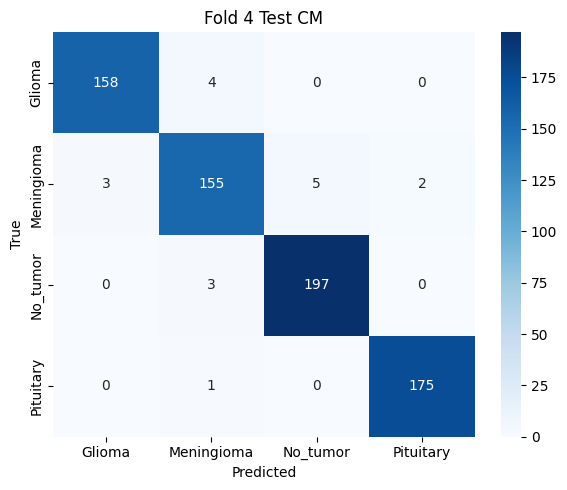

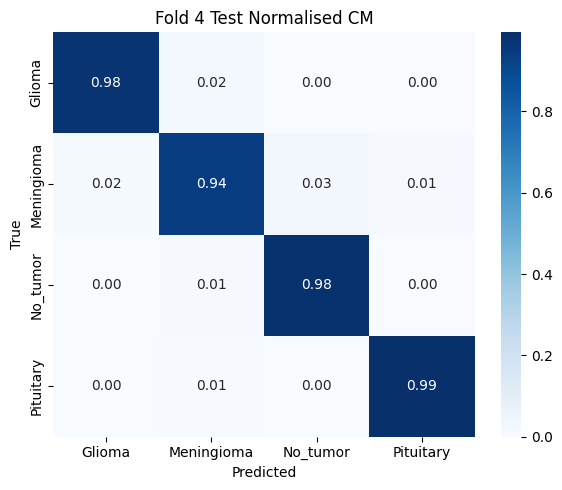

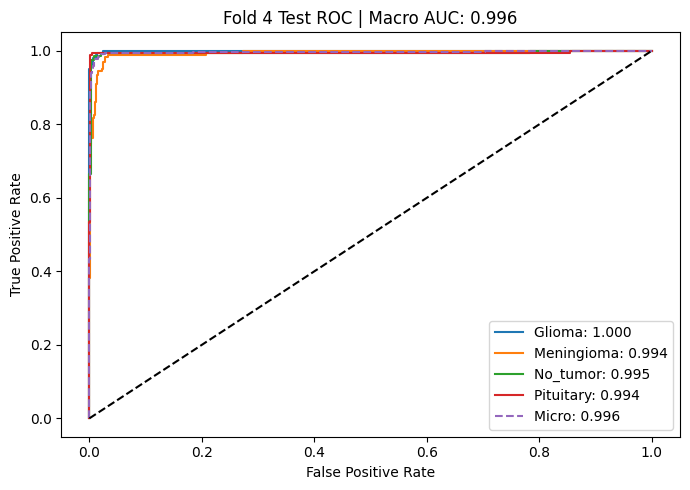


Metrics
Accuracy     0.974395
Precision    0.974316
Recall       0.974395
F1           0.974336
MCC          0.965783
Kappa        0.965770
LogLoss      0.120845
Macro_AUC    0.995617
Micro_AUC    0.995902
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          3           4
1  Meningioma          8          10
2    No_tumor          5           3
3   Pituitary          2           1


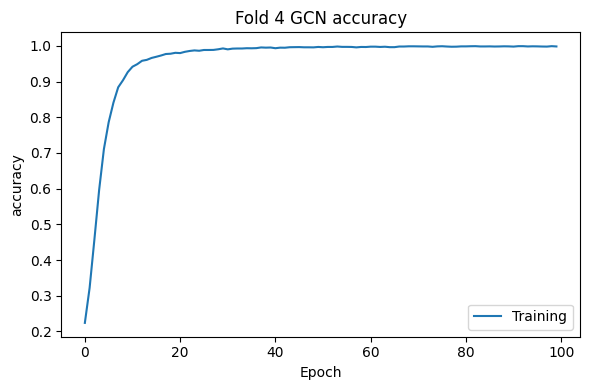

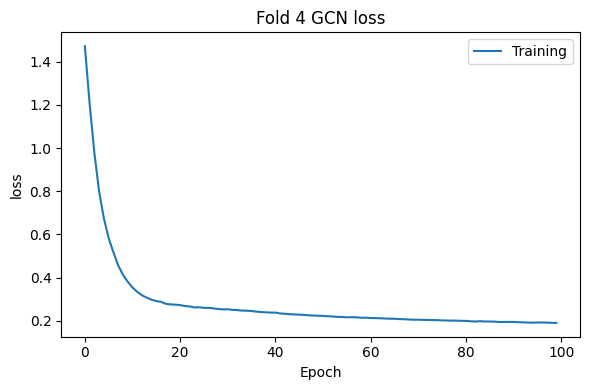


Graph Statistics
 {'Nodes': 7023, 'Edges': 5733, 'Average_Degree': 1.6326356258009398, 'Min_Degree': 0, 'Max_Degree': 18, 'Density': 0.00023250293731144115, 'Components': 3926, 'Largest_Component': 21}

Fold 5 Test
              precision    recall  f1-score     support
Glioma         0.981132  0.962963  0.971963  162.000000
Meningioma     0.923529  0.951515  0.937313  165.000000
No_tumor       0.970443  0.985000  0.977667  200.000000
Pituitary      1.000000  0.971591  0.985591  176.000000
accuracy       0.968706  0.968706  0.968706    0.968706
macro avg      0.968776  0.967767  0.968134  703.000000
weighted avg   0.969295  0.968706  0.968865  703.000000

Confusion Matrix
[[156   6   0   0]
 [  2 157   6   0]
 [  0   3 197   0]
 [  1   4   0 171]]


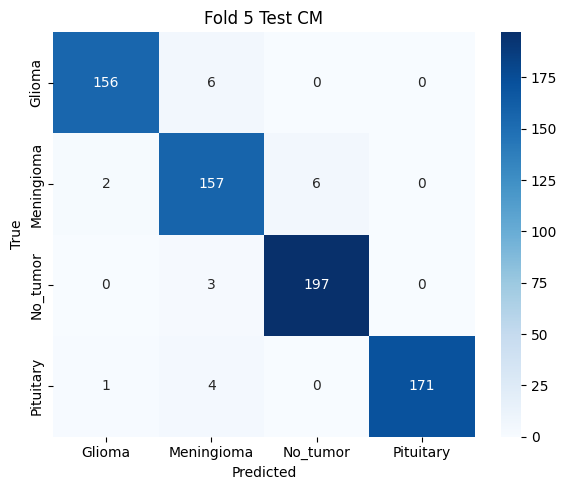

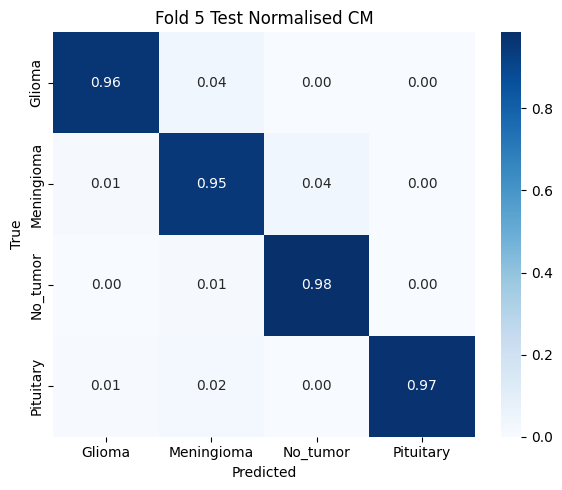

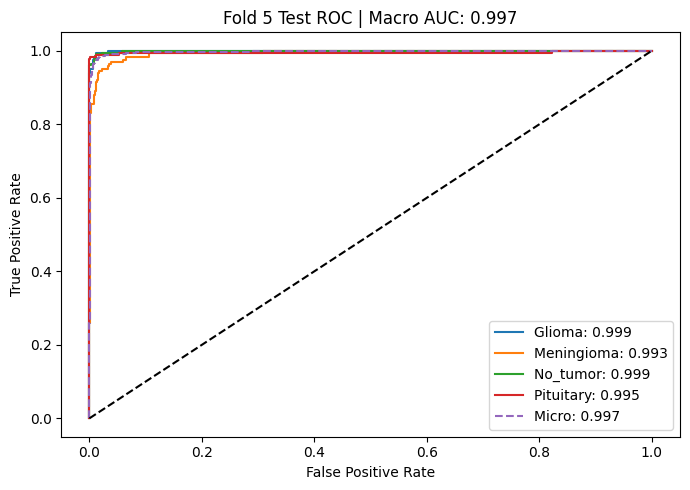


Metrics
Accuracy     0.968706
Precision    0.969295
Recall       0.968706
F1           0.968865
MCC          0.958255
Kappa        0.958167
LogLoss      0.127027
Macro_AUC    0.996725
Micro_AUC    0.996948
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          3           6
1  Meningioma         13           8
2    No_tumor          6           3
3   Pituitary          0           5


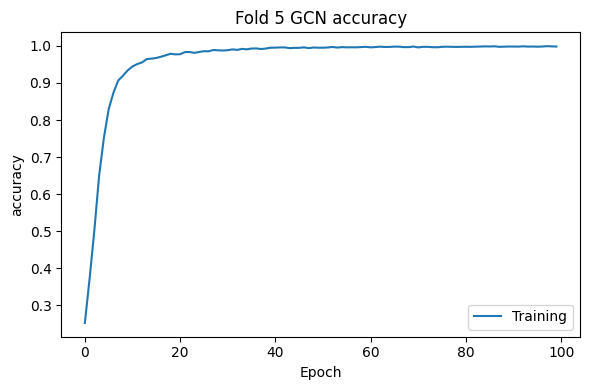

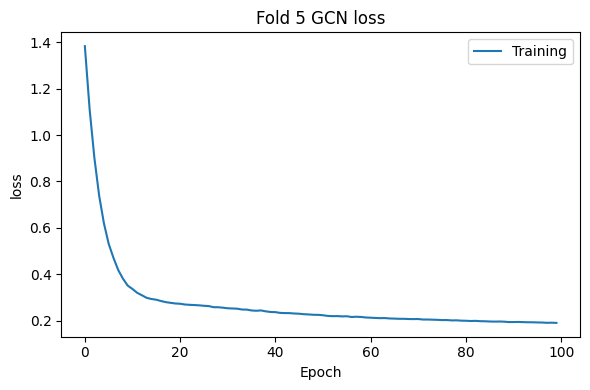


Graph Statistics
 {'Nodes': 7023, 'Edges': 5262, 'Average_Degree': 1.4985049124305851, 'Min_Degree': 0, 'Max_Degree': 17, 'Density': 0.00021340144010689052, 'Components': 4173, 'Largest_Component': 18}

Hybrid-GCN-Epsilon-Cosine Combined
              precision    recall  f1-score      support
Glioma         0.981273  0.970370  0.975791   810.000000
Meningioma     0.943099  0.944242  0.943671   825.000000
No_tumor       0.975198  0.983000  0.979084  1000.000000
Pituitary      0.982955  0.982955  0.982955   880.000000
accuracy       0.970982  0.970982  0.970982     0.970982
macro avg      0.970631  0.970142  0.970375  3515.000000
weighted avg   0.971006  0.970982  0.970982  3515.000000

Confusion Matrix
[[786  24   0   0]
 [ 11 779  23  12]
 [  1  13 983   3]
 [  3  10   2 865]]


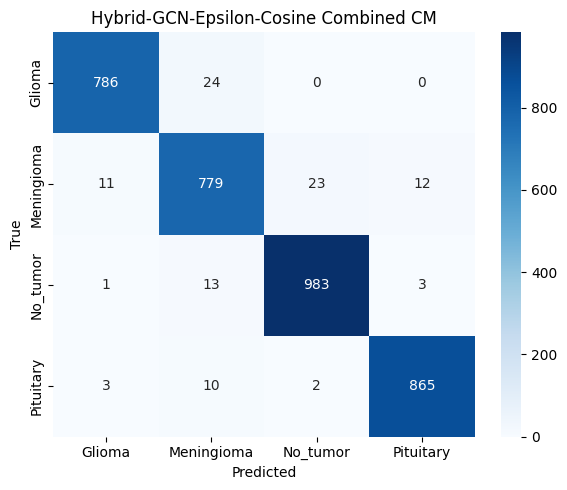

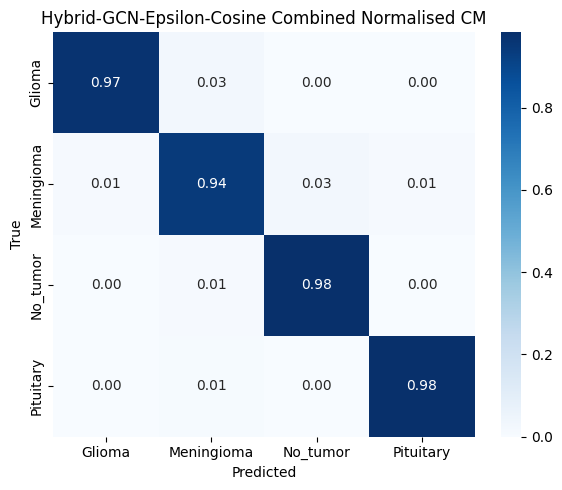

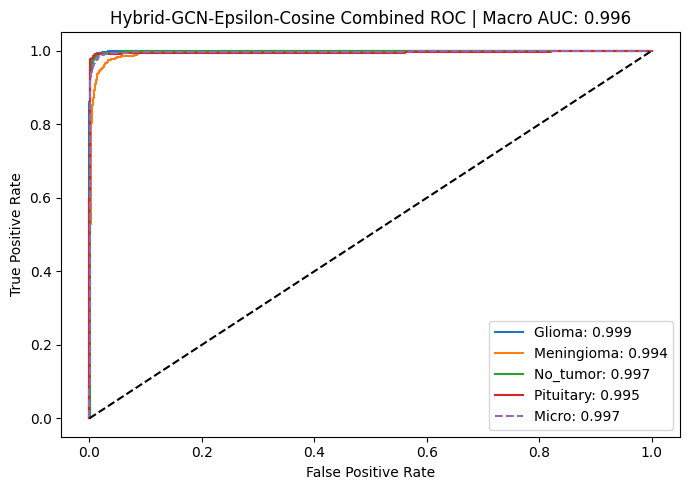


Metrics
Accuracy     0.970982
Precision    0.971006
Recall       0.970982
F1           0.970982
MCC          0.961216
Kappa        0.961209
LogLoss      0.122105
Macro_AUC    0.996382
Micro_AUC    0.996598
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma         15          24
1  Meningioma         47          46
2    No_tumor         25          17
3   Pituitary         15          15

5-FOLD RESULTS
Scores: [0.97866287 0.95874822 0.97439545 0.97439545 0.96870555]
Mean: 0.9709815078236131
SD: 0.006886895269934678
95% CI: (0.9614209644925031, 0.9805420511547231)

TIME
CNN: 7.048917237917582 min
GCN: 0.12891922473907472 min
Total: 7.177836462656657 min

COMPUTATIONAL METRICS
         Model  Parameters  Model_Size_MB  Nodes  Edges  Average_Degree  Density  Components  Largest_Component  GCN_FLOPs  GCN_GFLOPs  Inference_Time_sec  Latency_ms  Throughput_nodes_sec   RAM_GB
Hybrid-GCN-kNN       17156       0.065445   7023   5262        1.498505 0.000213     

In [2]:
import os, glob, gc, time, psutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, roc_curve, auc
)

from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter


# ============================================================
# CONFIG
# ============================================================

SEED=123
DATA_DIR=r"D:/GCN/Brain_Tumor/four_class"

IMG_SIZE=(150,150)
DOMAIN_SIZE=(64,64)

BATCH_SIZE=32
K_FOLDS=5
EPSILON=0.85
LR_CNN=1e-3
LR_GCN=0.005

EPOCHS_CNN=50
EPOCHS_GCN=100

DROPOUT=0.3
AUGMENT=True

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# DATA
# ============================================================
class_names=sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
class_to_idx={c:i for i,c in enumerate(class_names)}

paths,labels=[],[]
for c in class_names:
    for f in glob.glob(os.path.join(DATA_DIR,c,"*")):
        if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
            paths.append(f); labels.append(class_to_idx[c])

paths=np.asarray(paths); labels=np.asarray(labels,dtype=np.int32)
N=len(paths); NUM_CLASSES=len(class_names); all_indices=np.arange(N)

dev_indices,test_indices=train_test_split(all_indices,test_size=0.10,stratify=labels,random_state=SEED)
skf=StratifiedKFold(n_splits=K_FOLDS,shuffle=True,random_state=SEED)

print("Total:",N); print("Classes:",class_names); print("Distribution:",np.unique(labels,return_counts=True))
print("Development:",len(dev_indices)); print("Test:",len(test_indices))

# ============================================================
# IMAGE PIPELINE
# ============================================================
def load_img(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32)
    img=tf.image.resize(img,IMG_SIZE); img.set_shape([*IMG_SIZE,3])
    return img,label

def augment_img(img,label):
    if AUGMENT:
        img=tf.image.random_flip_left_right(img)
        img=tf.image.rot90(img,tf.random.uniform([],0,4,dtype=tf.int32))
    return img,label

def make_dataset(indices,training=False,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((paths[indices],labels[indices]))
    if shuffle: ds=ds.shuffle(len(indices),seed=SEED)
    ds=ds.map(load_img,num_parallel_calls=tf.data.AUTOTUNE)
    if training: ds=ds.map(augment_img,num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# gCNN-4
# ============================================================

def build_gcnn4():
    inp=Input(shape=(*IMG_SIZE,3))
    x=layers.Conv2D(32,3,padding="same",activation="relu")(inp); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(64,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(128,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(256,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.GlobalAveragePooling2D()(x)
    feature=layers.Dense(512,activation="relu",name="deep_feature")(x)
    output=layers.Dense(NUM_CLASSES,activation="softmax")(feature)
    return Model(inp,output,name="gCNN4"),Model(inp,feature,name="gCNN4_backbone")

def extract_deep_features(backbone,dataset):
    X,Y=[],[]
    for xb,yb in dataset:
        X.append(backbone(xb,training=False).numpy()); Y.append(yb.numpy())
    return np.vstack(X).astype(np.float32),np.concatenate(Y)


# ============================================================
# RAW + DOMAIN FEATURES
# ============================================================

def entropy_feature(gray):
    hist=tf.cast(tf.histogram_fixed_width(gray,[0.,1.],nbins=32),tf.float32)
    prob=hist/tf.reduce_sum(hist); prob=tf.where(prob>0,prob,tf.ones_like(prob))
    return -tf.reduce_sum(prob*tf.math.log(prob))

def extract_raw_domain(path):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32); img=tf.image.resize(img,IMG_SIZE)
    gray=tf.image.rgb_to_grayscale(img); raw=tf.reshape(gray,[-1]); small=tf.image.resize(gray,DOMAIN_SIZE)

    mean=tf.reduce_mean(small); std=tf.math.reduce_std(small); variance=tf.math.reduce_variance(small)
    minimum=tf.reduce_min(small); maximum=tf.reduce_max(small)

    sobel=tf.image.sobel_edges(tf.expand_dims(small,0))
    gradient=tf.sqrt(tf.reduce_sum(tf.square(sobel),axis=-1))
    edge=tf.reduce_mean(gradient); entropy=entropy_feature(small)

    domain=tf.stack([mean,std,variance,minimum,maximum,edge,entropy])
    return raw,tf.cast(domain,tf.float32)

def extract_raw_domain_features():
    raw,domain=[],[]; start=time.time()
    for i,p in enumerate(paths):
        r,d=extract_raw_domain(p); raw.append(r.numpy()); domain.append(d.numpy())
        if i%500==0: print("Processed:",i)
    print("Raw/domain extraction:",round((time.time()-start)/60,2),"min")
    return np.asarray(raw,dtype=np.float32),np.asarray(domain,dtype=np.float32)


# ============================================================
# FOLD-SPECIFIC FEATURE FUSION
# ============================================================

def fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_idx):

    def pca_branch(X):
        n=min(128,X.shape[1],len(train_idx)-1)
        pca=PCA(n_components=n,random_state=SEED); scaler=StandardScaler()
        tr=pca.fit_transform(X[train_idx]); va=pca.transform(X[val_idx]); te=pca.transform(X[test_idx])
        tr=scaler.fit_transform(tr); va=scaler.transform(va); te=scaler.transform(te)
        return tr,va,te

    deep_tr,deep_va,deep_te=pca_branch(X_deep)
    raw_tr,raw_va,raw_te=pca_branch(X_raw)

    scaler=StandardScaler()
    domain_tr=scaler.fit_transform(X_domain[train_idx])
    domain_va=scaler.transform(X_domain[val_idx]); domain_te=scaler.transform(X_domain[test_idx])

    X_train=np.concatenate([deep_tr,raw_tr,domain_tr],axis=1)
    X_val=np.concatenate([deep_va,raw_va,domain_va],axis=1)
    X_test=np.concatenate([deep_te,raw_te,domain_te],axis=1)

    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train); X_val=scaler.transform(X_val); X_test=scaler.transform(X_test)

    return X_train.astype(np.float32),X_val.astype(np.float32),X_test.astype(np.float32)

# ============================================================
# EPSILON COSINE GRAPH
# ============================================================

def build_epsilon_cosine_graph(X,epsilon=EPSILON):

    X=np.asarray(X,dtype=np.float32)

    norms=np.linalg.norm(X,axis=1,keepdims=True)
    norms=np.maximum(norms,1e-12)
    Xn=X/norms

    n=len(X)
    rows=[]
    cols=[]
    vals=[]

    for i in range(n):

        sim=Xn[i+1:] @ Xn[i]

        keep=np.where(sim>=epsilon)[0]

        for k in keep:

            j=i+1+k
            w=float(sim[k])

            rows.extend([i,j])
            cols.extend([j,i])
            vals.extend([w,w])

    A=coo_matrix(
        (vals,(rows,cols)),
        shape=(n,n),
        dtype=np.float32
    ).tocsr()

    A.setdiag(1.0)
    A.eliminate_zeros()

    return A


# ============================================================
# GRAPH HELPERS
# ============================================================
def sparse_adj(A):
    A=A.tocoo()
    S=tf.SparseTensor(indices=np.column_stack((A.row,A.col)).astype(np.int64),values=A.data.astype(np.float32),dense_shape=A.shape)
    return tf.sparse.reorder(S)

def graph_stats(A):
    A=A.copy().tocsr(); N=A.shape[0]; A.setdiag(0); A.eliminate_zeros()
    edges=A.nnz//2; degree=np.asarray((A>0).sum(axis=1)).ravel()
    components,cc=connected_components(A,directed=False,return_labels=True); sizes=np.bincount(cc)
    return {"Nodes":N,"Edges":edges,"Average_Degree":degree.mean(),"Min_Degree":degree.min(),"Max_Degree":degree.max(),
            "Density":2*edges/(N*(N-1)) if N>1 else 0,"Components":components,"Largest_Component":sizes.max()}


# ============================================================
# GCN
# ============================================================

def build_gcn(feature_dim,num_nodes):
    X_in=Input(shape=(feature_dim,),name="features"); A_in=Input(shape=(num_nodes,num_nodes),sparse=True,name="graph")
    x=GCNConv(64,activation="relu",kernel_regularizer=regularizers.l2(5e-4))([X_in,A_in]); x=layers.Dropout(DROPOUT)(x)
    out=GCNConv(NUM_CLASSES,activation="softmax")([x,A_in]); model=Model([X_in,A_in],out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_GCN),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),weighted_metrics=["accuracy"])
    return model
# ============================================================
# PLOTS + EVALUATION
# ============================================================
def plot_cm(cm,title,normalised=False):
    if normalised: cm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
    plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt=".2f" if normalised else "d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

def plot_roc(y_true,prob,title):
    y_bin=label_binarize(y_true,classes=np.arange(NUM_CLASSES)); plt.figure(figsize=(7,5)); aucs=[]
    for i in range(NUM_CLASSES):
        fpr,tpr,_=roc_curve(y_bin[:,i],prob[:,i]); a=auc(fpr,tpr); aucs.append(a); plt.plot(fpr,tpr,label=f"{class_names[i]}: {a:.3f}")
    fpr,tpr,_=roc_curve(y_bin.ravel(),prob.ravel()); micro=auc(fpr,tpr)
    plt.plot(fpr,tpr,"--",label=f"Micro: {micro:.3f}"); plt.plot([0,1],[0,1],"k--")
    plt.title(f"{title} | Macro AUC: {np.mean(aucs):.3f}"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend(); plt.tight_layout(); plt.show()
    return np.mean(aucs),micro

def plot_history(history,title):
    for metric in ["accuracy","loss"]:
        if metric not in history: continue
        plt.figure(figsize=(6,4)); plt.plot(history[metric],label="Training"); val_key="val_"+metric
        if val_key in history: plt.plot(history[val_key],label="Validation")
        plt.title(f"{title} {metric}"); plt.xlabel("Epoch"); plt.ylabel(metric); plt.legend(); plt.tight_layout(); plt.show()

def evaluate_results(y_true,y_pred,prob,title):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); prob=np.asarray(prob)
    print("\n"+"="*70); print(title); print("="*70)
    report=pd.DataFrame(classification_report(y_true,y_pred,target_names=class_names,output_dict=True,zero_division=0)).T; print(report)
    cm=confusion_matrix(y_true,y_pred); print("\nConfusion Matrix"); print(cm)
    plot_cm(cm,title+" CM"); plot_cm(cm,title+" Normalised CM",True); macro_auc,micro_auc=plot_roc(y_true,prob,title+" ROC")

    metrics={"Accuracy":accuracy_score(y_true,y_pred),"Precision":precision_score(y_true,y_pred,average="weighted",zero_division=0),
             "Recall":recall_score(y_true,y_pred,average="weighted",zero_division=0),"F1":f1_score(y_true,y_pred,average="weighted",zero_division=0),
             "MCC":matthews_corrcoef(y_true,y_pred),"Kappa":cohen_kappa_score(y_true,y_pred),
             "LogLoss":log_loss(y_true,prob,labels=np.arange(NUM_CLASSES)),"Macro_AUC":macro_auc,"Micro_AUC":micro_auc}

    print("\nMetrics"); print(pd.Series(metrics))
    FP=cm.sum(axis=0)-np.diag(cm); FN=cm.sum(axis=1)-np.diag(cm)
    print("\nError Analysis"); print(pd.DataFrame({"Class":class_names,"Type_I_FP":FP,"Type_II_FN":FN}))
    return report,metrics


# ============================================================
# FEATURE EXTRACTION
# ============================================================

print("\nExtracting raw/domain features"); X_raw,X_domain=extract_raw_domain_features()

# ============================================================
# 5-FOLD TRANSDUCTIVE TRAINING
# ============================================================
# ============================================================
# 5-FOLD TRANSDUCTIVE TRAINING
# ============================================================

fold_results=[]
final_model=None
final_X=None
final_A=None
final_graph_raw=None

for fold,(tr,val) in enumerate(skf.split(dev_indices,labels[dev_indices]),1):

    print(f"\n{'='*70}")
    print(f"FOLD {fold}")
    print("="*70)

    train_idx=dev_indices[tr]
    val_idx=dev_indices[val]

    tf.keras.backend.clear_session()
    gc.collect()

    train_ds=make_dataset(train_idx,training=True,shuffle=True)
    val_ds=make_dataset(val_idx)

    cnn,backbone=build_gcnn4()

    cnn.compile(optimizer=tf.keras.optimizers.Adam(LR_CNN),
                loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    start=time.time()
    cnn_hist=cnn.fit(train_ds,validation_data=val_ds,epochs=EPOCHS_CNN,
                     callbacks=[EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)],
                     verbose=1)
    cnn_time=time.time()-start

    X_deep,_=extract_deep_features(backbone,make_dataset(np.arange(N)))

    del cnn,backbone,train_ds,val_ds
    gc.collect()

    X_train,X_val,X_test=fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_indices)

    X_all=np.vstack([X_train,X_val,X_test])
    y_all=np.concatenate([labels[train_idx],labels[val_idx],labels[test_indices]])

    # epsilon-cosine graph
    A_graph=build_epsilon_cosine_graph(
        X_all,
        epsilon=EPSILON
    )

    A_norm=csr_matrix(
        gcn_filter(A_graph),
        dtype=np.float32
    )

    A=sparse_adj(A_norm)

    Y=to_categorical(y_all,NUM_CLASSES)

    mask=np.zeros(len(y_all),dtype=np.float32)
    mask[:len(train_idx)]=1.0

    gcn=build_gcn(X_all.shape[1],len(X_all))

    start=time.time()
    hist=gcn.fit([X_all,A],Y,sample_weight=mask,epochs=EPOCHS_GCN,
                 batch_size=len(X_all),shuffle=False,
                 callbacks=[EarlyStopping(monitor="loss",patience=30,restore_best_weights=True)],
                 verbose=1)
    gcn_time=time.time()-start

    prob=gcn([X_all,A],training=False).numpy()
    pred=np.argmax(prob,axis=1)

    test_start=len(train_idx)+len(val_idx)
    yt=y_all[test_start:]
    yp=pred[test_start:]
    pr=prob[test_start:]

    acc=accuracy_score(yt,yp)

    fold_results.append({
        "fold":fold,"true":yt,"pred":yp,"prob":pr,"accuracy":acc,
        "history":hist.history,"graph":graph_stats(A_graph),
        "cnn_time":cnn_time,"gcn_time":gcn_time
    })

    print(f"\nFold {fold} Test Accuracy: {acc:.4f}")

    final_model=gcn
    final_X=X_all
    final_A=A
    final_graph_raw=A_graph

    gc.collect()

print("\nTRAINING COMPLETED")


# ============================================================
# EACH FOLD
# ============================================================

for item in fold_results:

    evaluate_results(item["true"],item["pred"],item["prob"],f"Fold {item['fold']} Test")
    plot_history(item["history"],f"Fold {item['fold']} GCN")
    print("\nGraph Statistics\n",item["graph"])


# ============================================================
# COMBINED 5-FOLD TEST RESULTS
# ============================================================

y_true=np.concatenate([x["true"] for x in fold_results])
y_pred=np.concatenate([x["pred"] for x in fold_results])
prob=np.vstack([x["prob"] for x in fold_results])

final_report,final_metrics=evaluate_results(y_true,y_pred,prob,"Hybrid-GCN-Epsilon-Cosine Combined")


# ============================================================
# FOLD STATISTICS
# ============================================================

scores=np.asarray([x["accuracy"] for x in fold_results])

ci=stats.t.interval(0.95,len(scores)-1,loc=scores.mean(),scale=stats.sem(scores))

print("\n5-FOLD RESULTS")
print("Scores:",scores)
print("Mean:",scores.mean())
print("SD:",scores.std())
print("95% CI:",ci)


# ============================================================
# COMPUTATION TIME
# ============================================================

cnn_times=np.asarray([x["cnn_time"] for x in fold_results])
gcn_times=np.asarray([x["gcn_time"] for x in fold_results])

print("\nTIME")
print("CNN:",cnn_times.mean()/60,"min")
print("GCN:",gcn_times.mean()/60,"min")
print("Total:",(cnn_times.mean()+gcn_times.mean())/60,"min")


# ============================================================
# COMPUTATIONAL METRICS
# ============================================================

params=final_model.count_params()
model_size=params*4/(1024**2)

graph_info=graph_stats(final_graph_raw)
edges=graph_info["Edges"]
F=final_X.shape[1]

gcn_flops=2*edges*F*64+2*edges*64*NUM_CLASSES

start=time.time()
_=final_model([final_X,final_A],training=False)
inference_time=max(time.time()-start,1e-9)

nodes=len(final_X)

computational=pd.DataFrame([{
    "Model":"Hybrid-GCN-kNN",
    "Parameters":params,
    "Model_Size_MB":model_size,
    "Nodes":graph_info["Nodes"],
    "Edges":graph_info["Edges"],
    "Average_Degree":graph_info["Average_Degree"],
    "Density":graph_info["Density"],
    "Components":graph_info["Components"],
    "Largest_Component":graph_info["Largest_Component"],
    "GCN_FLOPs":gcn_flops,
    "GCN_GFLOPs":gcn_flops/1e9,
    "Inference_Time_sec":inference_time,
    "Latency_ms":1000*inference_time/nodes,
    "Throughput_nodes_sec":nodes/inference_time,
    "RAM_GB":psutil.Process(os.getpid()).memory_info().rss/1024**3
}])

print("\nCOMPUTATIONAL METRICS")
print(computational.to_string(index=False))


# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n"+"="*70)
print("EXPERIMENT 1 - HYBRID GCN EPSILON-COSINE")
print("="*70)
print("CNN                 : gCNN-4")
print("Deep features       : 512")
print("Raw features        : Grayscale pixels")
print("Domain features     : 7")
print("PCA                 : Max 128 per deep/raw branch")
print("Graph               : Epsilon-Cosine")
print("Epsilon threshold   :",EPSILON)
print("Metric              : Cosine similarity")
print("Edge condition      : similarity >= epsilon")
print("Weight              : Cosine similarity")
print("Symmetrization      : Undirected")
print("Self loops          : Yes")
print("GCN normalization   : gcn_filter")
print("GCN hidden units    : 64")
print("Dropout             :",DROPOUT)
print("GCN LR              :",LR_GCN)
print("Label smoothing     : 0.05")
print("Mode                : Transductive only")
print("Seed                :",SEED)
print("="*70)

Total: 7023
Classes: ['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']
Distribution: (array([0, 1, 2, 3]), array([1621, 1645, 2000, 1757], dtype=int64))
Development: 6320
Test: 703

Extracting raw/domain features
Processed: 0
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
Processed: 5500
Processed: 6000
Processed: 6500
Processed: 7000
Raw/domain extraction: 1.04 min

FOLD 1
Epoch 1/50
158/158 [==============================] - 8s 46ms/step - loss: 1.0691 - accuracy: 0.5053 - val_loss: 0.8510 - val_accuracy: 0.6646
Epoch 2/50
158/158 [==============================] - 7s 45ms/step - loss: 0.7770 - accuracy: 0.6841 - val_loss: 0.7198 - val_accuracy: 0.7373
Epoch 3/50
158/158 [==============================] - 7s 45ms/step - loss: 0.6975 - accuracy: 0.7241 - val_loss: 0.6731 - val_accuracy: 0.7453
Epoch 4/50
158/158 [==============================] - 7s 45ms/step - loss: 0.6069 

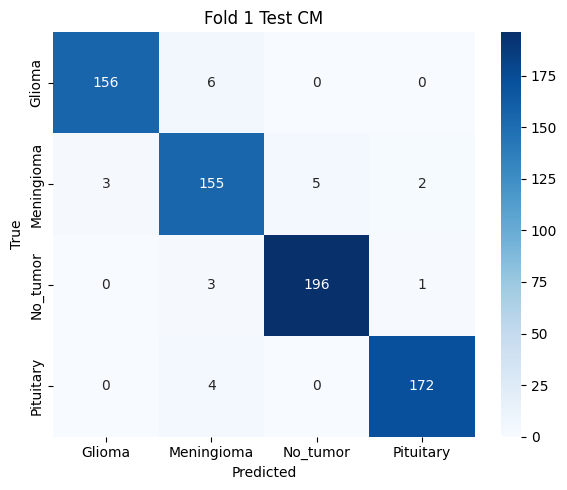

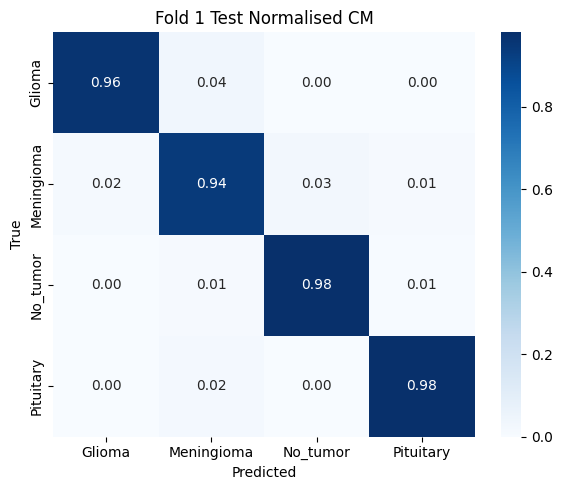

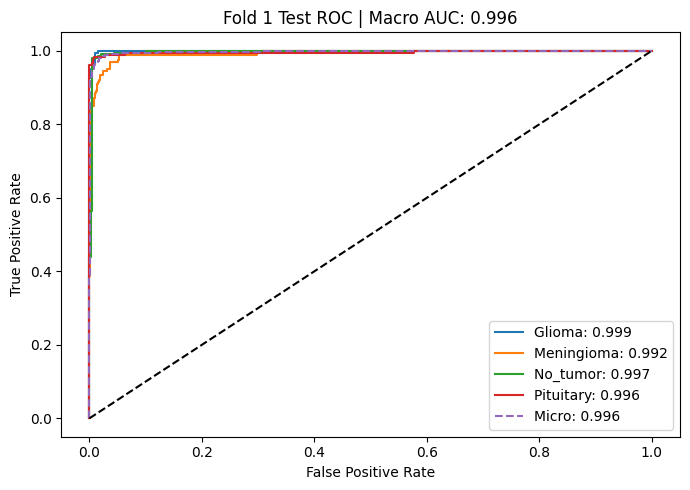


Metrics
Accuracy     0.965861
Precision    0.966121
Recall       0.965861
F1           0.965950
MCC          0.954393
Kappa        0.954367
LogLoss      0.134951
Macro_AUC    0.996204
Micro_AUC    0.996408
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          3           6
1  Meningioma         13          10
2    No_tumor          5           4
3   Pituitary          3           4


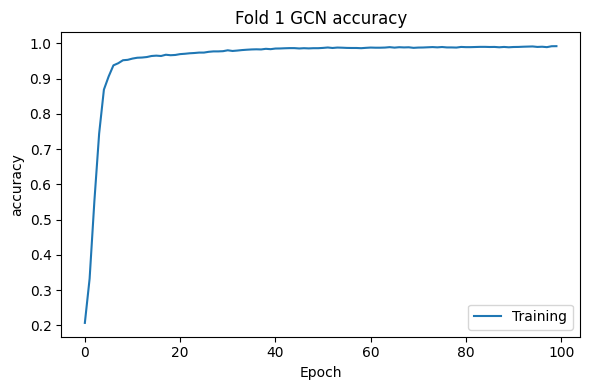

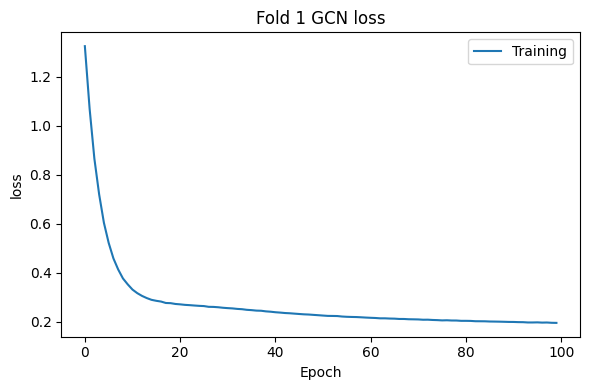


Graph Statistics
 {'Nodes': 7023, 'Edges': 53012, 'Average_Degree': 15.096682329488823, 'Min_Degree': 12, 'Max_Degree': 35, 'Density': 0.002149912037808149, 'Components': 1, 'Largest_Component': 7023}

Fold 2 Test
              precision    recall  f1-score     support
Glioma         0.975460  0.981481  0.978462  162.000000
Meningioma     0.939394  0.939394  0.939394  165.000000
No_tumor       0.975000  0.975000  0.975000  200.000000
Pituitary      0.982857  0.977273  0.980057  176.000000
accuracy       0.968706  0.968706  0.968706    0.968706
macro avg      0.968178  0.968287  0.968228  703.000000
weighted avg   0.968716  0.968706  0.968707  703.000000

Confusion Matrix
[[159   3   0   0]
 [  3 155   5   2]
 [  0   4 195   1]
 [  1   3   0 172]]


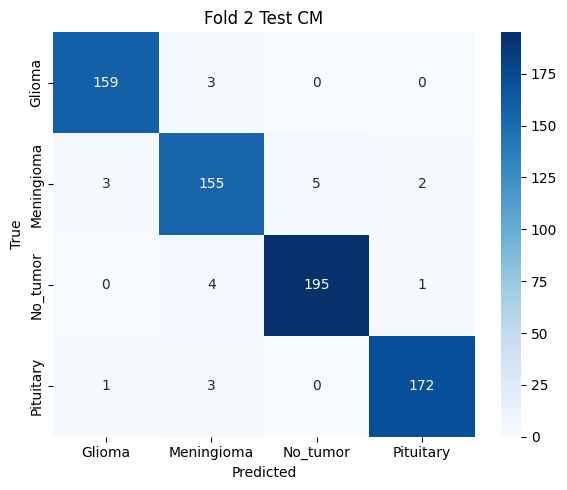

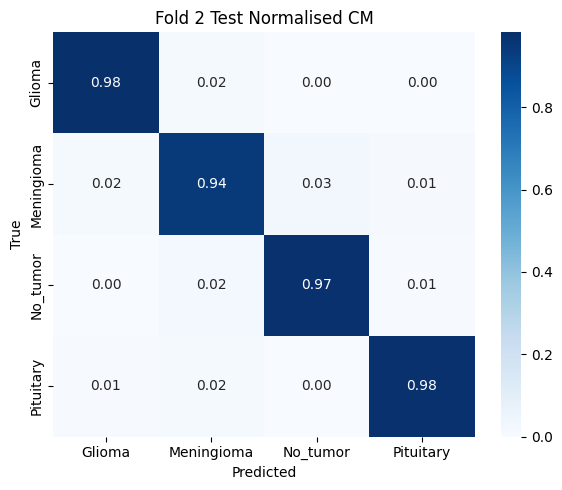

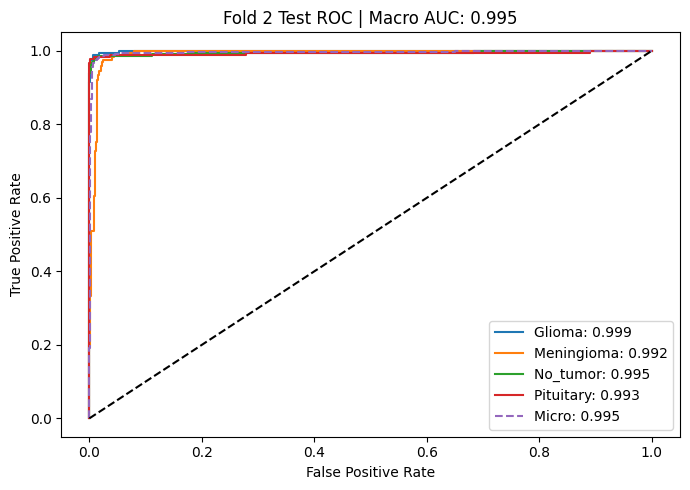


Metrics
Accuracy     0.968706
Precision    0.968716
Recall       0.968706
F1           0.968707
MCC          0.958177
Kappa        0.958175
LogLoss      0.132929
Macro_AUC    0.994925
Micro_AUC    0.995227
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          4           3
1  Meningioma         10          10
2    No_tumor          5           5
3   Pituitary          3           4


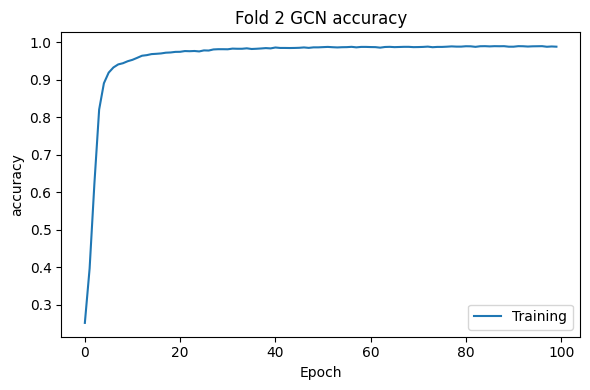

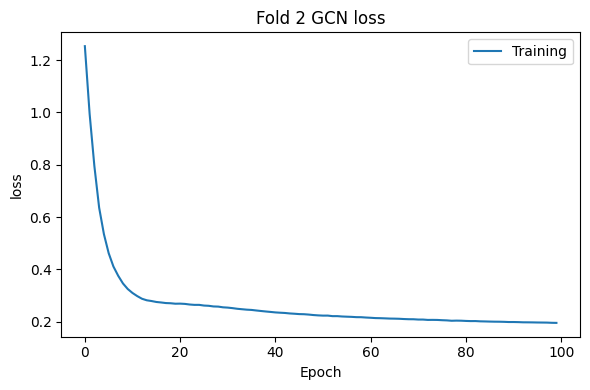


Graph Statistics
 {'Nodes': 7023, 'Edges': 53085, 'Average_Degree': 15.117471166168304, 'Min_Degree': 12, 'Max_Degree': 40, 'Density': 0.0021528725670988754, 'Components': 3, 'Largest_Component': 6960}

Fold 3 Test
              precision    recall  f1-score     support
Glioma         0.957317  0.969136  0.963190  162.000000
Meningioma     0.934524  0.951515  0.942943  165.000000
No_tumor       0.994924  0.980000  0.987406  200.000000
Pituitary      0.988506  0.977273  0.982857  176.000000
accuracy       0.970128  0.970128  0.970128    0.970128
macro avg      0.968818  0.969481  0.969099  703.000000
weighted avg   0.970475  0.970128  0.970251  703.000000

Confusion Matrix
[[157   5   0   0]
 [  6 157   1   1]
 [  0   3 196   1]
 [  1   3   0 172]]


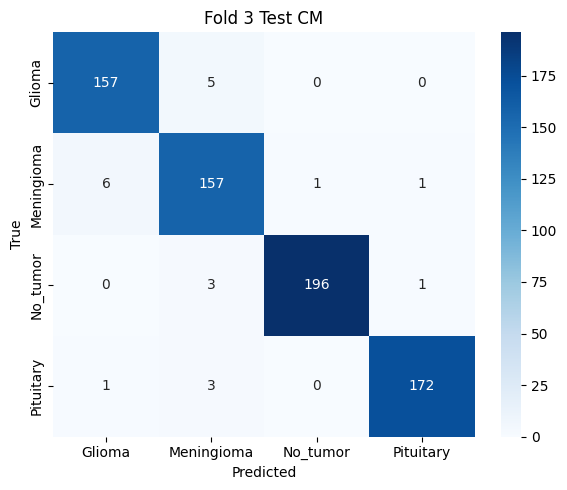

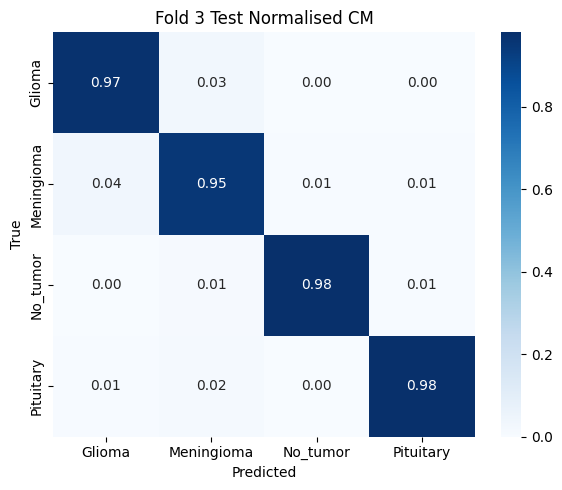

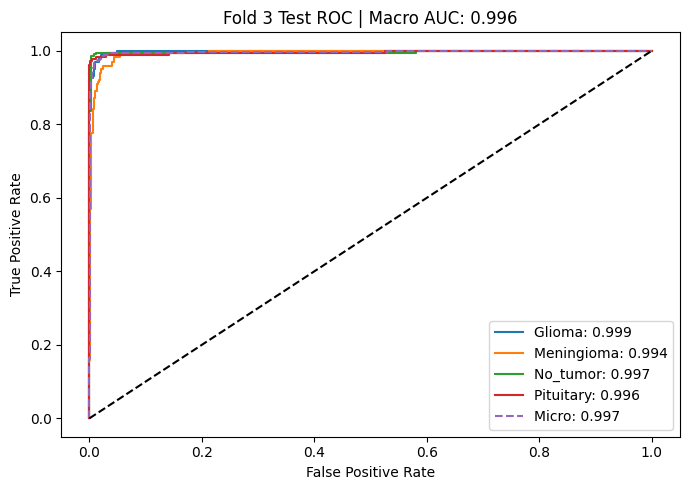


Metrics
Accuracy     0.970128
Precision    0.970475
Recall       0.970128
F1           0.970251
MCC          0.960123
Kappa        0.960089
LogLoss      0.131289
Macro_AUC    0.996217
Micro_AUC    0.996521
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          7           5
1  Meningioma         11           8
2    No_tumor          1           4
3   Pituitary          2           4


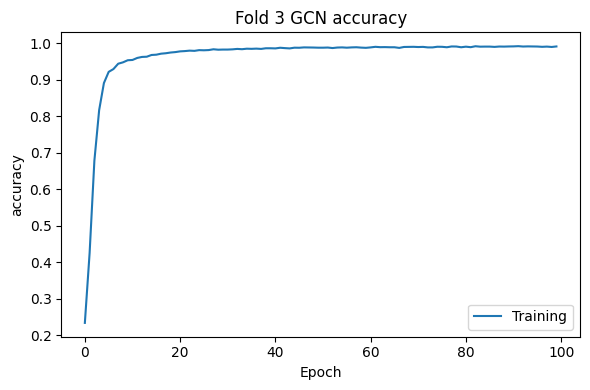

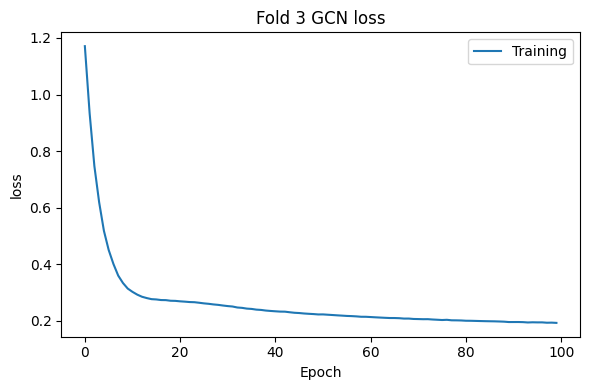


Graph Statistics
 {'Nodes': 7023, 'Edges': 53056, 'Average_Degree': 15.109212587213442, 'Min_Degree': 12, 'Max_Degree': 34, 'Density': 0.0021516964664217374, 'Components': 2, 'Largest_Component': 7002}

Fold 4 Test
              precision    recall  f1-score     support
Glioma         0.963190  0.969136  0.966154  162.000000
Meningioma     0.937500  0.909091  0.923077  165.000000
No_tumor       0.965174  0.970000  0.967581  200.000000
Pituitary      0.972067  0.988636  0.980282  176.000000
accuracy       0.960171  0.960171  0.960171    0.960171
macro avg      0.959483  0.959216  0.959273  703.000000
weighted avg   0.959947  0.960171  0.959986  703.000000

Confusion Matrix
[[157   5   0   0]
 [  5 150   6   4]
 [  1   4 194   1]
 [  0   1   1 174]]


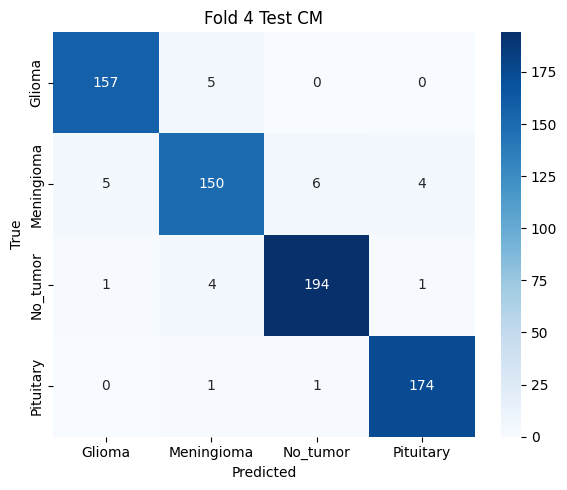

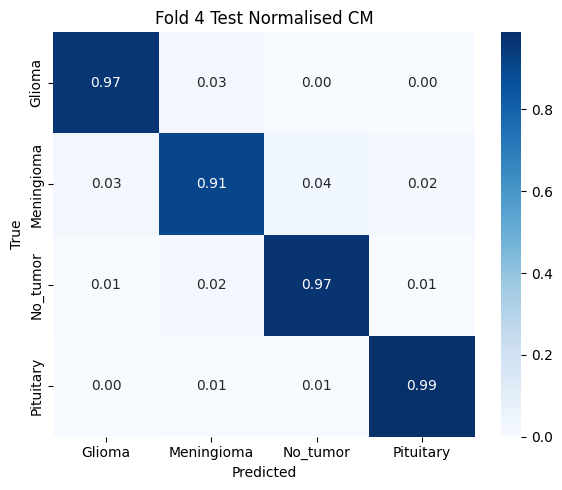

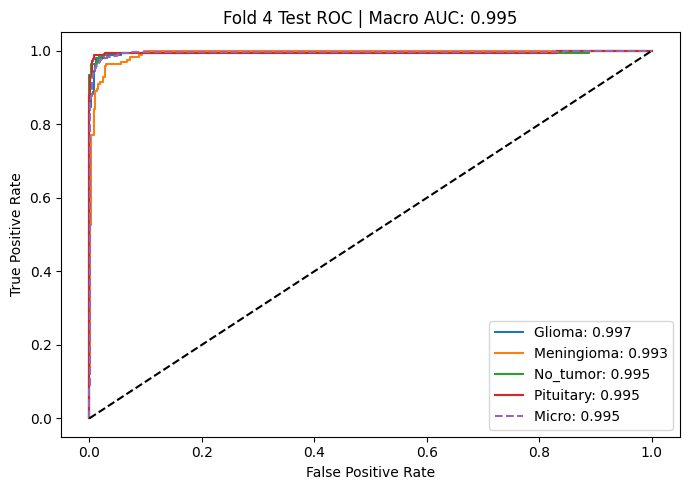


Metrics
Accuracy     0.960171
Precision    0.959947
Recall       0.960171
F1           0.959986
MCC          0.946803
Kappa        0.946757
LogLoss      0.145162
Macro_AUC    0.994951
Micro_AUC    0.995147
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          6           5
1  Meningioma         10          15
2    No_tumor          7           6
3   Pituitary          5           2


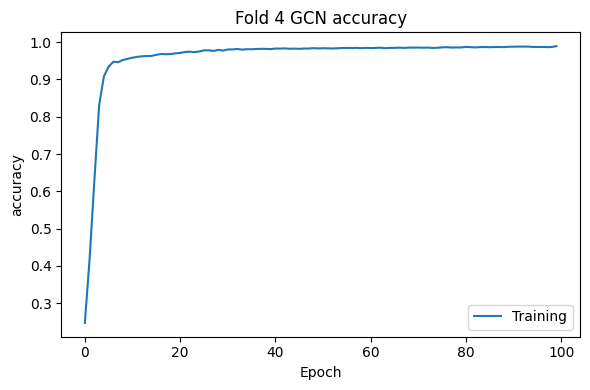

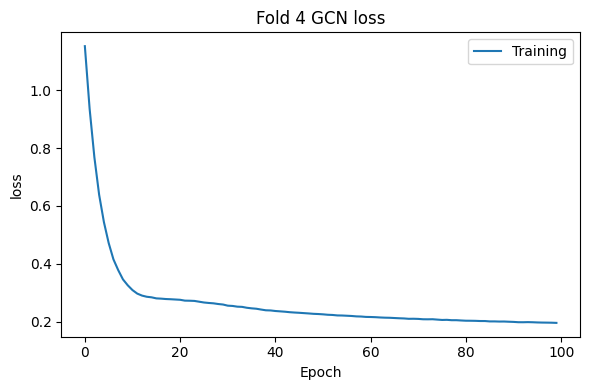


Graph Statistics
 {'Nodes': 7023, 'Edges': 53116, 'Average_Degree': 15.126299302292468, 'Min_Degree': 12, 'Max_Degree': 35, 'Density': 0.0021541297781675402, 'Components': 1, 'Largest_Component': 7023}

Fold 5 Test
              precision    recall  f1-score     support
Glioma         0.974843  0.956790  0.965732  162.000000
Meningioma     0.939394  0.939394  0.939394  165.000000
No_tumor       0.965686  0.985000  0.975248  200.000000
Pituitary      0.982857  0.977273  0.980057  176.000000
accuracy       0.965861  0.965861  0.965861    0.965861
macro avg      0.965695  0.964614  0.965108  703.000000
weighted avg   0.965924  0.965861  0.965844  703.000000

Confusion Matrix
[[155   7   0   0]
 [  3 155   5   2]
 [  1   1 197   1]
 [  0   2   2 172]]


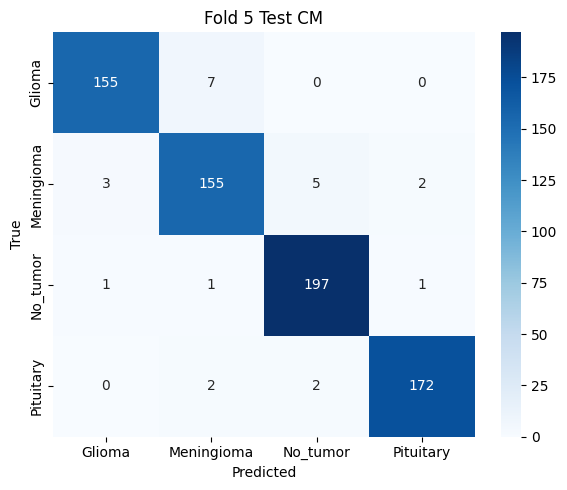

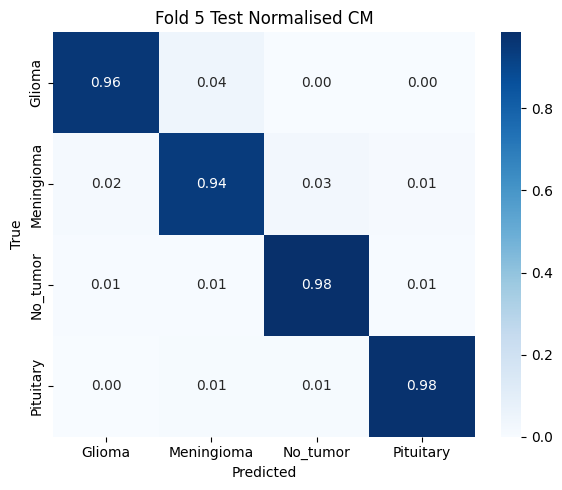

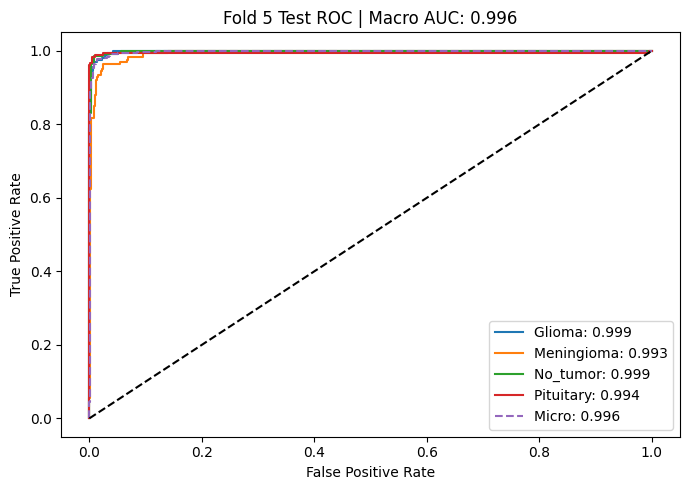


Metrics
Accuracy     0.965861
Precision    0.965924
Recall       0.965861
F1           0.965844
MCC          0.954388
Kappa        0.954354
LogLoss      0.135494
Macro_AUC    0.996205
Micro_AUC    0.996438
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma          4           7
1  Meningioma         10          10
2    No_tumor          7           3
3   Pituitary          3           4


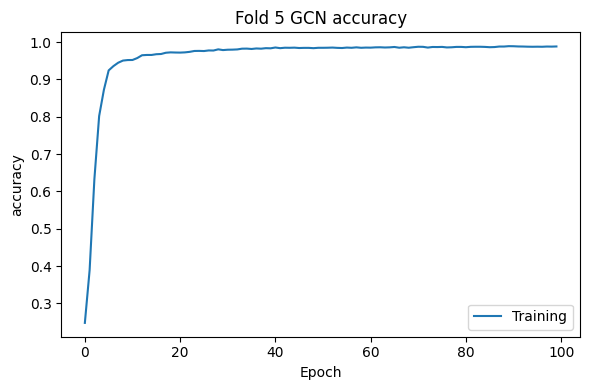

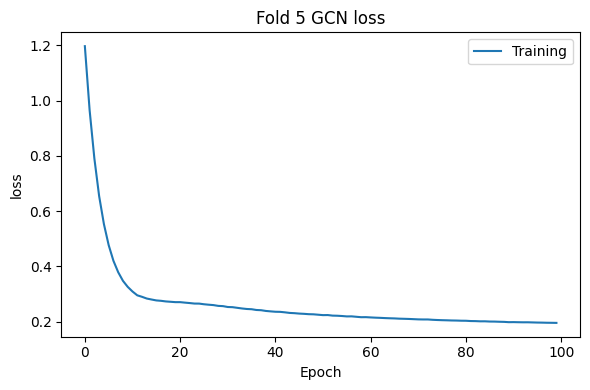


Graph Statistics
 {'Nodes': 7023, 'Edges': 52828, 'Average_Degree': 15.044283069913142, 'Min_Degree': 12, 'Max_Degree': 39, 'Density': 0.002142449881787688, 'Components': 1, 'Largest_Component': 7023}

Hybrid-GCN-RBF-Cosine Combined
              precision    recall  f1-score      support
Glioma         0.970297  0.967901  0.969098   810.000000
Meningioma     0.934625  0.935758  0.935191   825.000000
No_tumor       0.975075  0.978000  0.976535  1000.000000
Pituitary      0.981777  0.979545  0.980660   880.000000
accuracy       0.966145  0.966145  0.966145     0.966145
macro avg      0.965443  0.965301  0.965371  3515.000000
weighted avg   0.966158  0.966145  0.966150  3515.000000

Confusion Matrix
[[784  26   0   0]
 [ 20 772  22  11]
 [  2  15 978   5]
 [  2  13   3 862]]


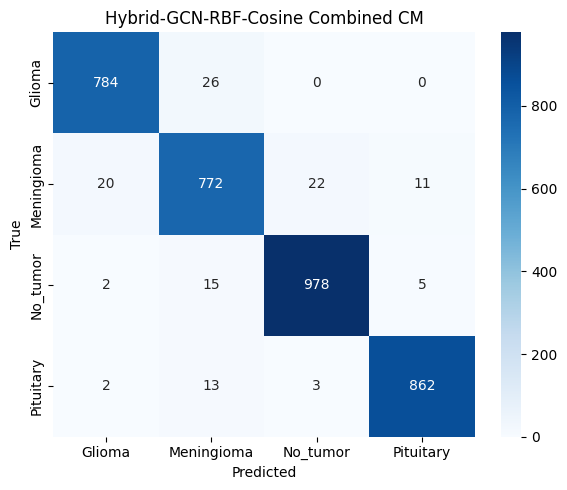

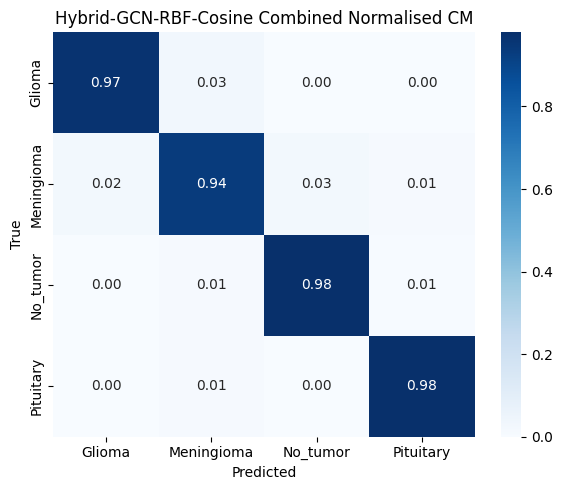

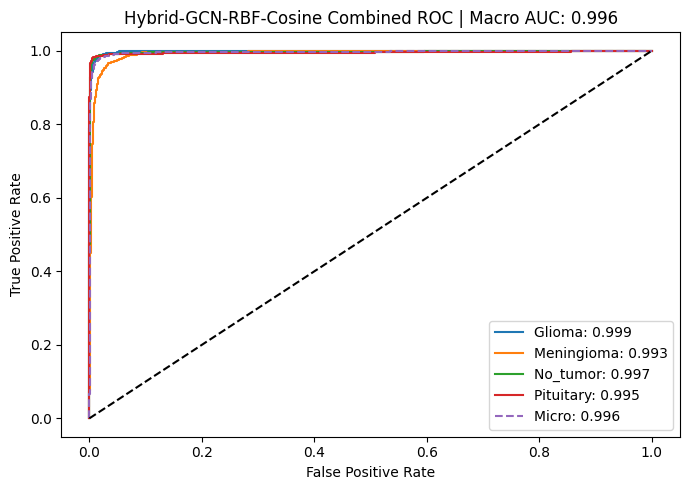


Metrics
Accuracy     0.966145
Precision    0.966158
Recall       0.966145
F1           0.966150
MCC          0.954750
Kappa        0.954749
LogLoss      0.135965
Macro_AUC    0.995709
Micro_AUC    0.995963
dtype: float64

Error Analysis
        Class  Type_I_FP  Type_II_FN
0      Glioma         24          26
1  Meningioma         54          53
2    No_tumor         25          22
3   Pituitary         16          18

5-FOLD RESULTS
Scores: [0.9658606  0.96870555 0.97012802 0.9601707  0.9658606 ]
Mean: 0.966145092460882
SD: 0.003413940256045546
95% CI: (0.9614057836042142, 0.9708844013175497)

TIME
CNN: 6.135897716681162 min
GCN: 0.0928229808807373 min
Total: 6.2287206975619 min

COMPUTATIONAL METRICS
         Model  Parameters  Model_Size_MB  Nodes  Edges  Average_Degree  Density  Components  Largest_Component  GCN_FLOPs  GCN_GFLOPs  Inference_Time_sec  Latency_ms  Throughput_nodes_sec   RAM_GB
Hybrid-GCN-kNN       17156       0.065445   7023  52828       15.044283 0.002142         

NameError: name 'GAMMA' is not defined

In [3]:
import os, glob, gc, time, psutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, roc_curve, auc
)

from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter
from sklearn.neighbors import radius_neighbors_graph

# ============================================================
# CONFIG
# ============================================================

SEED=123
DATA_DIR=r"D:/GCN/Brain_Tumor/four_class"

IMG_SIZE=(150,150)
DOMAIN_SIZE=(64,64)

BATCH_SIZE=32
K_FOLDS=5
LR_CNN=1e-3
LR_GCN=0.005

EPOCHS_CNN=50
EPOCHS_GCN=100

DROPOUT=0.3
AUGMENT=True

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# DATA
# ============================================================
class_names=sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
class_to_idx={c:i for i,c in enumerate(class_names)}

paths,labels=[],[]
for c in class_names:
    for f in glob.glob(os.path.join(DATA_DIR,c,"*")):
        if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
            paths.append(f); labels.append(class_to_idx[c])

paths=np.asarray(paths); labels=np.asarray(labels,dtype=np.int32)
N=len(paths); NUM_CLASSES=len(class_names); all_indices=np.arange(N)

dev_indices,test_indices=train_test_split(all_indices,test_size=0.10,stratify=labels,random_state=SEED)
skf=StratifiedKFold(n_splits=K_FOLDS,shuffle=True,random_state=SEED)

print("Total:",N); print("Classes:",class_names); print("Distribution:",np.unique(labels,return_counts=True))
print("Development:",len(dev_indices)); print("Test:",len(test_indices))

# ============================================================
# IMAGE PIPELINE
# ============================================================
def load_img(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32)
    img=tf.image.resize(img,IMG_SIZE); img.set_shape([*IMG_SIZE,3])
    return img,label

def augment_img(img,label):
    if AUGMENT:
        img=tf.image.random_flip_left_right(img)
        img=tf.image.rot90(img,tf.random.uniform([],0,4,dtype=tf.int32))
    return img,label

def make_dataset(indices,training=False,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((paths[indices],labels[indices]))
    if shuffle: ds=ds.shuffle(len(indices),seed=SEED)
    ds=ds.map(load_img,num_parallel_calls=tf.data.AUTOTUNE)
    if training: ds=ds.map(augment_img,num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# gCNN-4
# ============================================================

def build_gcnn4():
    inp=Input(shape=(*IMG_SIZE,3))
    x=layers.Conv2D(32,3,padding="same",activation="relu")(inp); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(64,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(128,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(256,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.GlobalAveragePooling2D()(x)
    feature=layers.Dense(512,activation="relu",name="deep_feature")(x)
    output=layers.Dense(NUM_CLASSES,activation="softmax")(feature)
    return Model(inp,output,name="gCNN4"),Model(inp,feature,name="gCNN4_backbone")

def extract_deep_features(backbone,dataset):
    X,Y=[],[]
    for xb,yb in dataset:
        X.append(backbone(xb,training=False).numpy()); Y.append(yb.numpy())
    return np.vstack(X).astype(np.float32),np.concatenate(Y)


# ============================================================
# RAW + DOMAIN FEATURES
# ============================================================

def entropy_feature(gray):
    hist=tf.cast(tf.histogram_fixed_width(gray,[0.,1.],nbins=32),tf.float32)
    prob=hist/tf.reduce_sum(hist); prob=tf.where(prob>0,prob,tf.ones_like(prob))
    return -tf.reduce_sum(prob*tf.math.log(prob))

def extract_raw_domain(path):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32); img=tf.image.resize(img,IMG_SIZE)
    gray=tf.image.rgb_to_grayscale(img); raw=tf.reshape(gray,[-1]); small=tf.image.resize(gray,DOMAIN_SIZE)

    mean=tf.reduce_mean(small); std=tf.math.reduce_std(small); variance=tf.math.reduce_variance(small)
    minimum=tf.reduce_min(small); maximum=tf.reduce_max(small)

    sobel=tf.image.sobel_edges(tf.expand_dims(small,0))
    gradient=tf.sqrt(tf.reduce_sum(tf.square(sobel),axis=-1))
    edge=tf.reduce_mean(gradient); entropy=entropy_feature(small)

    domain=tf.stack([mean,std,variance,minimum,maximum,edge,entropy])
    return raw,tf.cast(domain,tf.float32)

def extract_raw_domain_features():
    raw,domain=[],[]; start=time.time()
    for i,p in enumerate(paths):
        r,d=extract_raw_domain(p); raw.append(r.numpy()); domain.append(d.numpy())
        if i%500==0: print("Processed:",i)
    print("Raw/domain extraction:",round((time.time()-start)/60,2),"min")
    return np.asarray(raw,dtype=np.float32),np.asarray(domain,dtype=np.float32)


# ============================================================
# FOLD-SPECIFIC FEATURE FUSION
# ============================================================

def fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_idx):

    def pca_branch(X):
        n=min(128,X.shape[1],len(train_idx)-1)
        pca=PCA(n_components=n,random_state=SEED); scaler=StandardScaler()
        tr=pca.fit_transform(X[train_idx]); va=pca.transform(X[val_idx]); te=pca.transform(X[test_idx])
        tr=scaler.fit_transform(tr); va=scaler.transform(va); te=scaler.transform(te)
        return tr,va,te

    deep_tr,deep_va,deep_te=pca_branch(X_deep)
    raw_tr,raw_va,raw_te=pca_branch(X_raw)

    scaler=StandardScaler()
    domain_tr=scaler.fit_transform(X_domain[train_idx])
    domain_va=scaler.transform(X_domain[val_idx]); domain_te=scaler.transform(X_domain[test_idx])

    X_train=np.concatenate([deep_tr,raw_tr,domain_tr],axis=1)
    X_val=np.concatenate([deep_va,raw_va,domain_va],axis=1)
    X_test=np.concatenate([deep_te,raw_te,domain_te],axis=1)

    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train); X_val=scaler.transform(X_val); X_test=scaler.transform(X_test)

    return X_train.astype(np.float32),X_val.astype(np.float32),X_test.astype(np.float32)

# ============================================================
# RBF-COSINE GRAPH
# ============================================================

K_RBF = 12
SIGMA_MODE = "auto"
SIGMA_FIXED = 1.0
MIN_WEIGHT = 1e-6

def build_rbf_cosine_graph(X):

    X = np.asarray(X, dtype=np.float32)
    n = len(X)

    nbrs = NearestNeighbors(
        n_neighbors=min(K_RBF + 1, n),
        metric="cosine",
        n_jobs=-1
    )

    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X, return_distance=True)

    if SIGMA_MODE == "auto":
        nonzero_distances = distances[:, 1:].reshape(-1)
        nonzero_distances = nonzero_distances[nonzero_distances > 0]
        sigma_rbf = float(np.median(nonzero_distances))
    else:
        sigma_rbf = float(SIGMA_FIXED)

    sigma_rbf = max(sigma_rbf, 1e-8)

    rows = []
    cols = []
    vals = []

    denominator = 2.0 * sigma_rbf * sigma_rbf

    for i in range(n):
        for j, distance in zip(indices[i], distances[i]):

            if i == j:
                continue

            weight = np.exp(
                -(float(distance) ** 2) / denominator
            )

            if weight < MIN_WEIGHT:
                continue

            rows.append(i)
            cols.append(j)
            vals.append(weight)

    A_dir = coo_matrix(
        (np.asarray(vals, dtype=np.float32),
         (np.asarray(rows), np.asarray(cols))),
        shape=(n, n),
        dtype=np.float32
    ).tocsr()

    A = A_dir.maximum(A_dir.T)
    A.setdiag(1.0)
    A.eliminate_zeros()

    return A, sigma_rbf

# ============================================================
# GRAPH HELPERS
# ============================================================
def sparse_adj(A):
    A=A.tocoo()
    S=tf.SparseTensor(indices=np.column_stack((A.row,A.col)).astype(np.int64),values=A.data.astype(np.float32),dense_shape=A.shape)
    return tf.sparse.reorder(S)

def graph_stats(A):
    A=A.copy().tocsr(); N=A.shape[0]; A.setdiag(0); A.eliminate_zeros()
    edges=A.nnz//2; degree=np.asarray((A>0).sum(axis=1)).ravel()
    components,cc=connected_components(A,directed=False,return_labels=True); sizes=np.bincount(cc)
    return {"Nodes":N,"Edges":edges,"Average_Degree":degree.mean(),"Min_Degree":degree.min(),"Max_Degree":degree.max(),
            "Density":2*edges/(N*(N-1)) if N>1 else 0,"Components":components,"Largest_Component":sizes.max()}


# ============================================================
# GCN
# ============================================================

def build_gcn(feature_dim,num_nodes):
    X_in=Input(shape=(feature_dim,),name="features"); A_in=Input(shape=(num_nodes,num_nodes),sparse=True,name="graph")
    x=GCNConv(64,activation="relu",kernel_regularizer=regularizers.l2(5e-4))([X_in,A_in]); x=layers.Dropout(DROPOUT)(x)
    out=GCNConv(NUM_CLASSES,activation="softmax")([x,A_in]); model=Model([X_in,A_in],out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_GCN),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),weighted_metrics=["accuracy"])
    return model
# ============================================================
# PLOTS + EVALUATION
# ============================================================
def plot_cm(cm,title,normalised=False):
    if normalised: cm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
    plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt=".2f" if normalised else "d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

def plot_roc(y_true,prob,title):
    y_bin=label_binarize(y_true,classes=np.arange(NUM_CLASSES)); plt.figure(figsize=(7,5)); aucs=[]
    for i in range(NUM_CLASSES):
        fpr,tpr,_=roc_curve(y_bin[:,i],prob[:,i]); a=auc(fpr,tpr); aucs.append(a); plt.plot(fpr,tpr,label=f"{class_names[i]}: {a:.3f}")
    fpr,tpr,_=roc_curve(y_bin.ravel(),prob.ravel()); micro=auc(fpr,tpr)
    plt.plot(fpr,tpr,"--",label=f"Micro: {micro:.3f}"); plt.plot([0,1],[0,1],"k--")
    plt.title(f"{title} | Macro AUC: {np.mean(aucs):.3f}"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend(); plt.tight_layout(); plt.show()
    return np.mean(aucs),micro

def plot_history(history,title):
    for metric in ["accuracy","loss"]:
        if metric not in history: continue
        plt.figure(figsize=(6,4)); plt.plot(history[metric],label="Training"); val_key="val_"+metric
        if val_key in history: plt.plot(history[val_key],label="Validation")
        plt.title(f"{title} {metric}"); plt.xlabel("Epoch"); plt.ylabel(metric); plt.legend(); plt.tight_layout(); plt.show()

def evaluate_results(y_true,y_pred,prob,title):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); prob=np.asarray(prob)
    print("\n"+"="*70); print(title); print("="*70)
    report=pd.DataFrame(classification_report(y_true,y_pred,target_names=class_names,output_dict=True,zero_division=0)).T; print(report)
    cm=confusion_matrix(y_true,y_pred); print("\nConfusion Matrix"); print(cm)
    plot_cm(cm,title+" CM"); plot_cm(cm,title+" Normalised CM",True); macro_auc,micro_auc=plot_roc(y_true,prob,title+" ROC")

    metrics={"Accuracy":accuracy_score(y_true,y_pred),"Precision":precision_score(y_true,y_pred,average="weighted",zero_division=0),
             "Recall":recall_score(y_true,y_pred,average="weighted",zero_division=0),"F1":f1_score(y_true,y_pred,average="weighted",zero_division=0),
             "MCC":matthews_corrcoef(y_true,y_pred),"Kappa":cohen_kappa_score(y_true,y_pred),
             "LogLoss":log_loss(y_true,prob,labels=np.arange(NUM_CLASSES)),"Macro_AUC":macro_auc,"Micro_AUC":micro_auc}

    print("\nMetrics"); print(pd.Series(metrics))
    FP=cm.sum(axis=0)-np.diag(cm); FN=cm.sum(axis=1)-np.diag(cm)
    print("\nError Analysis"); print(pd.DataFrame({"Class":class_names,"Type_I_FP":FP,"Type_II_FN":FN}))
    return report,metrics


# ============================================================
# FEATURE EXTRACTION
# ============================================================

print("\nExtracting raw/domain features"); X_raw,X_domain=extract_raw_domain_features()

# ============================================================
# 5-FOLD TRANSDUCTIVE TRAINING
# ============================================================

fold_results=[]
final_model=None
final_X=None
final_A=None
final_graph_raw=None

for fold,(tr,val) in enumerate(skf.split(dev_indices,labels[dev_indices]),1):

    print(f"\n{'='*70}")
    print(f"FOLD {fold}")
    print("="*70)

    train_idx=dev_indices[tr]
    val_idx=dev_indices[val]

    tf.keras.backend.clear_session()
    gc.collect()

    train_ds=make_dataset(train_idx,training=True,shuffle=True)
    val_ds=make_dataset(val_idx)

    cnn,backbone=build_gcnn4()

    cnn.compile(optimizer=tf.keras.optimizers.Adam(LR_CNN),
                loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    start=time.time()
    cnn_hist=cnn.fit(train_ds,validation_data=val_ds,epochs=EPOCHS_CNN,
                     callbacks=[EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)],
                     verbose=1)
    cnn_time=time.time()-start

    X_deep,_=extract_deep_features(backbone,make_dataset(np.arange(N)))

    del cnn,backbone,train_ds,val_ds
    gc.collect()

    X_train,X_val,X_test=fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_indices)

    X_all=np.vstack([X_train,X_val,X_test])
    y_all=np.concatenate([labels[train_idx],labels[val_idx],labels[test_indices]])

    A_graph, sigma_rbf = build_rbf_cosine_graph(X_all)

    A_norm = csr_matrix(
        gcn_filter(A_graph),
        dtype=np.float32
    )

    A = sparse_adj(A_norm)


    Y=to_categorical(y_all,NUM_CLASSES)

    mask=np.zeros(len(y_all),dtype=np.float32)
    mask[:len(train_idx)]=1.0

    gcn=build_gcn(X_all.shape[1],len(X_all))

    start=time.time()
    hist=gcn.fit([X_all,A],Y,sample_weight=mask,epochs=EPOCHS_GCN,
                 batch_size=len(X_all),shuffle=False,
                 callbacks=[EarlyStopping(monitor="loss",patience=30,restore_best_weights=True)],
                 verbose=1)
    gcn_time=time.time()-start

    prob=gcn([X_all,A],training=False).numpy()
    pred=np.argmax(prob,axis=1)

    test_start=len(train_idx)+len(val_idx)
    yt=y_all[test_start:]
    yp=pred[test_start:]
    pr=prob[test_start:]

    acc=accuracy_score(yt,yp)

    fold_results.append({
        "fold":fold,"true":yt,"pred":yp,"prob":pr,"accuracy":acc,
        "history":hist.history,"graph":graph_stats(A_graph),
        "cnn_time":cnn_time,"gcn_time":gcn_time
    })

    print(f"\nFold {fold} Test Accuracy: {acc:.4f}")

    final_model=gcn
    final_X=X_all
    final_A=A
    final_graph_raw=A_graph

    gc.collect()

print("\nTRAINING COMPLETED")


# ============================================================
# EACH FOLD
# ============================================================

for item in fold_results:

    evaluate_results(item["true"],item["pred"],item["prob"],f"Fold {item['fold']} Test")
    plot_history(item["history"],f"Fold {item['fold']} GCN")
    print("\nGraph Statistics\n",item["graph"])


# ============================================================
# COMBINED 5-FOLD TEST RESULTS
# ============================================================

y_true=np.concatenate([x["true"] for x in fold_results])
y_pred=np.concatenate([x["pred"] for x in fold_results])
prob=np.vstack([x["prob"] for x in fold_results])

final_report,final_metrics=evaluate_results(y_true,y_pred,prob,"Hybrid-GCN-RBF-Cosine Combined")


# ============================================================
# FOLD STATISTICS
# ============================================================

scores=np.asarray([x["accuracy"] for x in fold_results])

ci=stats.t.interval(0.95,len(scores)-1,loc=scores.mean(),scale=stats.sem(scores))

print("\n5-FOLD RESULTS")
print("Scores:",scores)
print("Mean:",scores.mean())
print("SD:",scores.std())
print("95% CI:",ci)


# ============================================================
# COMPUTATION TIME
# ============================================================

cnn_times=np.asarray([x["cnn_time"] for x in fold_results])
gcn_times=np.asarray([x["gcn_time"] for x in fold_results])

print("\nTIME")
print("CNN:",cnn_times.mean()/60,"min")
print("GCN:",gcn_times.mean()/60,"min")
print("Total:",(cnn_times.mean()+gcn_times.mean())/60,"min")


# ============================================================
# COMPUTATIONAL METRICS
# ============================================================

params=final_model.count_params()
model_size=params*4/(1024**2)

graph_info=graph_stats(final_graph_raw)
edges=graph_info["Edges"]
F=final_X.shape[1]

gcn_flops=2*edges*F*64+2*edges*64*NUM_CLASSES

start=time.time()
_=final_model([final_X,final_A],training=False)
inference_time=max(time.time()-start,1e-9)

nodes=len(final_X)

computational=pd.DataFrame([{
    "Model":"Hybrid-GCN-kNN",
    "Parameters":params,
    "Model_Size_MB":model_size,
    "Nodes":graph_info["Nodes"],
    "Edges":graph_info["Edges"],
    "Average_Degree":graph_info["Average_Degree"],
    "Density":graph_info["Density"],
    "Components":graph_info["Components"],
    "Largest_Component":graph_info["Largest_Component"],
    "GCN_FLOPs":gcn_flops,
    "GCN_GFLOPs":gcn_flops/1e9,
    "Inference_Time_sec":inference_time,
    "Latency_ms":1000*inference_time/nodes,
    "Throughput_nodes_sec":nodes/inference_time,
    "RAM_GB":psutil.Process(os.getpid()).memory_info().rss/1024**3
}])

print("\nCOMPUTATIONAL METRICS")
print(computational.to_string(index=False))
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n"+"="*70)
print("EXPERIMENT 1 - HYBRID GCN RBF-COSINE")
print("="*70)

print("Architecture")
print("CNN                 : gCNN-4")
print("GCN layers          : 2")
print("GCN hidden units    : 64")
print("Output classes      :",NUM_CLASSES)
print("Dropout             :",DROPOUT)

print("\nFeature Engineering")
print("Deep features       : 512")
print("Raw features        : Grayscale pixels")
print("Domain features     : 7")
print("Domain size         :",DOMAIN_SIZE)
print("PCA                 : Max 128 per deep/raw branch")
print("Feature fusion      : Deep + Raw + Domain")
print("Final feature dim   :",final_X.shape[1])
print("Standardization     : Yes")

print("\nGraph Construction")
print("Graph               : RBF-Cosine")
print("Distance metric     : Cosine distance")
print("Kernel              : Radial Basis Function (RBF)")
print("Gamma               :",GAMMA)
print("Edge weight         : exp(-gamma * cosine_distance^2)")
print("Graph type          : Weighted")
print("Graph direction     : Undirected")
print("Self loops          : Yes")
print("GCN normalization   : gcn_filter")

print("\nGraph Statistics")
print("Nodes               :",graph_info["Nodes"])
print("Edges               :",graph_info["Edges"])
print("Average degree      :",graph_info["Average_Degree"])
print("Minimum degree      :",graph_info["Min_Degree"])
print("Maximum degree      :",graph_info["Max_Degree"])
print("Density             :",graph_info["Density"])
print("Components          :",graph_info["Components"])
print("Largest component   :",graph_info["Largest_Component"])

print("\nTraining Configuration")
print("CNN learning rate   :",LR_CNN)
print("GCN learning rate   :",LR_GCN)
print("CNN epochs          :",EPOCHS_CNN)
print("GCN epochs          :",EPOCHS_GCN)
print("Batch size          :",BATCH_SIZE)
print("Label smoothing     : 0.05")
print("L2 regularization   : 5e-4")
print("Data augmentation   :",AUGMENT)
print("Cross-validation    :",K_FOLDS,"fold")
print("Mode                : Transductive")
print("Test split          : 10%")
print("Seed                :",SEED)

print("\nComputational Information")
print("Parameters          :",params)
print("Model size (MB)     :",model_size)
print("GCN FLOPs           :",gcn_flops)
print("GCN GFLOPs          :",gcn_flops/1e9)
print("Inference time (s)  :",inference_time)
print("Latency (ms/node)   :",1000*inference_time/nodes)
print("Throughput          :",nodes/inference_time,"nodes/sec")
print("RAM (GB)            :",psutil.Process(os.getpid()).memory_info().rss/1024**3)

print("\n5-Fold Performance")
print("Fold scores         :",scores)
print("Mean accuracy       :",scores.mean())
print("Standard deviation  :",scores.std())
print("95% CI              :",ci)

print("\nTiming")
print("Mean CNN time (min) :",cnn_times.mean()/60)
print("Mean GCN time (min) :",gcn_times.mean()/60)
print("Mean total time     :",(cnn_times.mean()+gcn_times.mean())/60,"min")

print("="*70)

In [5]:
# ============================================================
# COMPLETE MEMORY / CACHE / VARIABLE CLEANUP
# ============================================================

import os, gc, time, psutil
def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 1475.60 MB
Variable count  : 152
Variables       : A, AUGMENT, A_graph, A_norm, BATCH_SIZE, DATA_DIR, DOMAIN_SIZE, DROPOUT, EPOCHS_CNN, EPOCHS_GCN, EPSILON, EarlyStopping, F, GCNConv, IMG_SIZE, Input, K_DOMAIN, K_FOLDS, K_RBF, LR_CNN, LR_GCN, MIN_WEIGHT, Model, N, NUM_CLASSES, NearestNeighbors, PCA, SEED, SIGMA_FIXED, SIGMA_MODE, StandardScaler, StratifiedKFold, X_all, X_deep, X_domain, X_raw, X_test, X_train, X_val, Y, acc, accuracy_score, all_indices, auc, augment_img, build_domain_cosine_graph, build_epsilon_cosine_graph, build_gcn, build_gcnn4, build_rbf_cosine_graph, c, ci, class_names, class_to_idx, classification_report, clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, cnn_hist, cnn_time, cnn_times, cohen_kappa_score, computational, confusion_matrix, connected_components, coo_matrix, csr_matrix, delete_model

In [6]:
import os, glob, gc, time, psutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, roc_curve, auc
)

from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter
from sklearn.neighbors import radius_neighbors_graph

# ============================================================
# CONFIG
# ============================================================

SEED=123
DATA_DIR=r"D:/GCN/Brain_Tumor/four_class"

IMG_SIZE=(150,150)
DOMAIN_SIZE=(64,64)

BATCH_SIZE=32
K_FOLDS=5
LR_CNN=1e-3
LR_GCN=0.005

EPOCHS_CNN=50
EPOCHS_GCN=100

DROPOUT=0.3
AUGMENT=True

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# DATA
# ============================================================
class_names=sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
class_to_idx={c:i for i,c in enumerate(class_names)}

paths,labels=[],[]
for c in class_names:
    for f in glob.glob(os.path.join(DATA_DIR,c,"*")):
        if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
            paths.append(f); labels.append(class_to_idx[c])

paths=np.asarray(paths); labels=np.asarray(labels,dtype=np.int32)
N=len(paths); NUM_CLASSES=len(class_names); all_indices=np.arange(N)

dev_indices,test_indices=train_test_split(all_indices,test_size=0.10,stratify=labels,random_state=SEED)
skf=StratifiedKFold(n_splits=K_FOLDS,shuffle=True,random_state=SEED)

print("Total:",N); print("Classes:",class_names); print("Distribution:",np.unique(labels,return_counts=True))
print("Development:",len(dev_indices)); print("Test:",len(test_indices))

# ============================================================
# IMAGE PIPELINE
# ============================================================
def load_img(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32)
    img=tf.image.resize(img,IMG_SIZE); img.set_shape([*IMG_SIZE,3])
    return img,label

def augment_img(img,label):
    if AUGMENT:
        img=tf.image.random_flip_left_right(img)
        img=tf.image.rot90(img,tf.random.uniform([],0,4,dtype=tf.int32))
    return img,label

def make_dataset(indices,training=False,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((paths[indices],labels[indices]))
    if shuffle: ds=ds.shuffle(len(indices),seed=SEED)
    ds=ds.map(load_img,num_parallel_calls=tf.data.AUTOTUNE)
    if training: ds=ds.map(augment_img,num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# gCNN-4
# ============================================================

def build_gcnn4():
    inp=Input(shape=(*IMG_SIZE,3))
    x=layers.Conv2D(32,3,padding="same",activation="relu")(inp); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(64,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(128,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(256,3,padding="same",activation="relu")(x); x=layers.MaxPooling2D()(x)
    x=layers.GlobalAveragePooling2D()(x)
    feature=layers.Dense(512,activation="relu",name="deep_feature")(x)
    output=layers.Dense(NUM_CLASSES,activation="softmax")(feature)
    return Model(inp,output,name="gCNN4"),Model(inp,feature,name="gCNN4_backbone")

def extract_deep_features(backbone,dataset):
    X,Y=[],[]
    for xb,yb in dataset:
        X.append(backbone(xb,training=False).numpy()); Y.append(yb.numpy())
    return np.vstack(X).astype(np.float32),np.concatenate(Y)


# ============================================================
# RAW + DOMAIN FEATURES
# ============================================================

def entropy_feature(gray):
    hist=tf.cast(tf.histogram_fixed_width(gray,[0.,1.],nbins=32),tf.float32)
    prob=hist/tf.reduce_sum(hist); prob=tf.where(prob>0,prob,tf.ones_like(prob))
    return -tf.reduce_sum(prob*tf.math.log(prob))

def extract_raw_domain(path):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.convert_image_dtype(img,tf.float32); img=tf.image.resize(img,IMG_SIZE)
    gray=tf.image.rgb_to_grayscale(img); raw=tf.reshape(gray,[-1]); small=tf.image.resize(gray,DOMAIN_SIZE)

    mean=tf.reduce_mean(small); std=tf.math.reduce_std(small); variance=tf.math.reduce_variance(small)
    minimum=tf.reduce_min(small); maximum=tf.reduce_max(small)

    sobel=tf.image.sobel_edges(tf.expand_dims(small,0))
    gradient=tf.sqrt(tf.reduce_sum(tf.square(sobel),axis=-1))
    edge=tf.reduce_mean(gradient); entropy=entropy_feature(small)

    domain=tf.stack([mean,std,variance,minimum,maximum,edge,entropy])
    return raw,tf.cast(domain,tf.float32)

def extract_raw_domain_features():
    raw,domain=[],[]; start=time.time()
    for i,p in enumerate(paths):
        r,d=extract_raw_domain(p); raw.append(r.numpy()); domain.append(d.numpy())
        if i%500==0: print("Processed:",i)
    print("Raw/domain extraction:",round((time.time()-start)/60,2),"min")
    return np.asarray(raw,dtype=np.float32),np.asarray(domain,dtype=np.float32)


# ============================================================
# FOLD-SPECIFIC FEATURE FUSION
# ============================================================

def fold_feature_fusion(X_deep,X_raw,X_domain,train_idx,val_idx,test_idx):

    def pca_branch(X):
        n=min(128,X.shape[1],len(train_idx)-1)
        pca=PCA(n_components=n,random_state=SEED); scaler=StandardScaler()
        tr=pca.fit_transform(X[train_idx]); va=pca.transform(X[val_idx]); te=pca.transform(X[test_idx])
        tr=scaler.fit_transform(tr); va=scaler.transform(va); te=scaler.transform(te)
        return tr,va,te

    deep_tr,deep_va,deep_te=pca_branch(X_deep)
    raw_tr,raw_va,raw_te=pca_branch(X_raw)

    scaler=StandardScaler()
    domain_tr=scaler.fit_transform(X_domain[train_idx])
    domain_va=scaler.transform(X_domain[val_idx]); domain_te=scaler.transform(X_domain[test_idx])

    X_train=np.concatenate([deep_tr,raw_tr,domain_tr],axis=1)
    X_val=np.concatenate([deep_va,raw_va,domain_va],axis=1)
    X_test=np.concatenate([deep_te,raw_te,domain_te],axis=1)

    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train); X_val=scaler.transform(X_val); X_test=scaler.transform(X_test)

    return X_train.astype(np.float32),X_val.astype(np.float32),X_test.astype(np.float32)

# ============================================================
# DOMAIN-COSINE GRAPH
# ============================================================

K_DOMAIN = 12

def build_domain_cosine_graph(X_domain_graph):

    X = np.asarray(X_domain_graph, dtype=np.float32)
    n = len(X)

    nbrs = NearestNeighbors(
        n_neighbors=min(K_DOMAIN + 1, n),
        metric="cosine",
        n_jobs=-1
    )

    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X, return_distance=True)

    rows = []
    cols = []
    vals = []

    for i in range(n):

        for j, distance in zip(indices[i], distances[i]):

            if i == j:
                continue

            similarity = 1.0 - float(distance)

            if similarity <= 0:
                continue

            rows.append(i)
            cols.append(j)
            vals.append(similarity)

    A_dir = coo_matrix(
        (
            np.asarray(vals, dtype=np.float32),
            (
                np.asarray(rows, dtype=np.int32),
                np.asarray(cols, dtype=np.int32)
            )
        ),
        shape=(n, n),
        dtype=np.float32
    ).tocsr()

    A = A_dir.maximum(A_dir.T)

    A.setdiag(1.0)
    A.eliminate_zeros()

    return A
# ============================================================
# GRAPH HELPERS
# ============================================================
def sparse_adj(A):
    A=A.tocoo()
    S=tf.SparseTensor(indices=np.column_stack((A.row,A.col)).astype(np.int64),values=A.data.astype(np.float32),dense_shape=A.shape)
    return tf.sparse.reorder(S)

def graph_stats(A):
    A=A.copy().tocsr(); N=A.shape[0]; A.setdiag(0); A.eliminate_zeros()
    edges=A.nnz//2; degree=np.asarray((A>0).sum(axis=1)).ravel()
    components,cc=connected_components(A,directed=False,return_labels=True); sizes=np.bincount(cc)
    return {"Nodes":N,"Edges":edges,"Average_Degree":degree.mean(),"Min_Degree":degree.min(),"Max_Degree":degree.max(),
            "Density":2*edges/(N*(N-1)) if N>1 else 0,"Components":components,"Largest_Component":sizes.max()}


# ============================================================
# GCN
# ============================================================

def build_gcn(feature_dim,num_nodes):
    X_in=Input(shape=(feature_dim,),name="features"); A_in=Input(shape=(num_nodes,num_nodes),sparse=True,name="graph")
    x=GCNConv(64,activation="relu",kernel_regularizer=regularizers.l2(5e-4))([X_in,A_in]); x=layers.Dropout(DROPOUT)(x)
    out=GCNConv(NUM_CLASSES,activation="softmax")([x,A_in]); model=Model([X_in,A_in],out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_GCN),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),weighted_metrics=["accuracy"])
    return model
# ============================================================
# PLOTS + EVALUATION
# ============================================================
def plot_cm(cm,title,normalised=False):
    if normalised: cm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
    plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt=".2f" if normalised else "d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

def plot_roc(y_true,prob,title):
    y_bin=label_binarize(y_true,classes=np.arange(NUM_CLASSES)); plt.figure(figsize=(7,5)); aucs=[]
    for i in range(NUM_CLASSES):
        fpr,tpr,_=roc_curve(y_bin[:,i],prob[:,i]); a=auc(fpr,tpr); aucs.append(a); plt.plot(fpr,tpr,label=f"{class_names[i]}: {a:.3f}")
    fpr,tpr,_=roc_curve(y_bin.ravel(),prob.ravel()); micro=auc(fpr,tpr)
    plt.plot(fpr,tpr,"--",label=f"Micro: {micro:.3f}"); plt.plot([0,1],[0,1],"k--")
    plt.title(f"{title} | Macro AUC: {np.mean(aucs):.3f}"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend(); plt.tight_layout(); plt.show()
    return np.mean(aucs),micro

def plot_history(history,title):
    for metric in ["accuracy","loss"]:
        if metric not in history: continue
        plt.figure(figsize=(6,4)); plt.plot(history[metric],label="Training"); val_key="val_"+metric
        if val_key in history: plt.plot(history[val_key],label="Validation")
        plt.title(f"{title} {metric}"); plt.xlabel("Epoch"); plt.ylabel(metric); plt.legend(); plt.tight_layout(); plt.show()

def evaluate_results(y_true,y_pred,prob,title):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); prob=np.asarray(prob)
    print("\n"+"="*70); print(title); print("="*70)
    report=pd.DataFrame(classification_report(y_true,y_pred,target_names=class_names,output_dict=True,zero_division=0)).T; print(report)
    cm=confusion_matrix(y_true,y_pred); print("\nConfusion Matrix"); print(cm)
    plot_cm(cm,title+" CM"); plot_cm(cm,title+" Normalised CM",True); macro_auc,micro_auc=plot_roc(y_true,prob,title+" ROC")

    metrics={"Accuracy":accuracy_score(y_true,y_pred),"Precision":precision_score(y_true,y_pred,average="weighted",zero_division=0),
             "Recall":recall_score(y_true,y_pred,average="weighted",zero_division=0),"F1":f1_score(y_true,y_pred,average="weighted",zero_division=0),
             "MCC":matthews_corrcoef(y_true,y_pred),"Kappa":cohen_kappa_score(y_true,y_pred),
             "LogLoss":log_loss(y_true,prob,labels=np.arange(NUM_CLASSES)),"Macro_AUC":macro_auc,"Micro_AUC":micro_auc}

    print("\nMetrics"); print(pd.Series(metrics))
    FP=cm.sum(axis=0)-np.diag(cm); FN=cm.sum(axis=1)-np.diag(cm)
    print("\nError Analysis"); print(pd.DataFrame({"Class":class_names,"Type_I_FP":FP,"Type_II_FN":FN}))
    return report,metrics


# ============================================================
# FEATURE EXTRACTION
# ============================================================

print("\nExtracting raw/domain features"); X_raw,X_domain=extract_raw_domain_features()

# ============================================================
# 5-FOLD TRANSDUCTIVE TRAINING
# ============================================================

fold_results=[]
final_model=None
final_X=None
final_A=None
final_graph_raw=None

for fold,(tr,val) in enumerate(skf.split(dev_indices,labels[dev_indices]),1):

    print(f"\n{'='*70}")
    print(f"FOLD {fold}")
    print("="*70)

    train_idx=dev_indices[tr]
    val_idx=dev_indices[val]

    tf.keras.backend.clear_session()
    gc.collect()

    train_ds=make_dataset(train_idx,training=True,shuffle=True)
    val_ds=make_dataset(val_idx)

    cnn,backbone=build_gcnn4()

    cnn.compile(optimizer=tf.keras.optimizers.Adam(LR_CNN),
                loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    start=time.time()
    cnn_hist=cnn.fit(train_ds,validation_data=val_ds,epochs=EPOCHS_CNN,
                     callbacks=[EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)],
                     verbose=1)
    cnn_time=time.time()-start

    X_deep,_=extract_deep_features(backbone,make_dataset(np.arange(N)))

    del cnn,backbone,train_ds,val_ds
    gc.collect()

    X_train,X_val,X_test=fold_feature_fusion(
    X_deep,
    X_raw,
    X_domain,
    train_idx,
    val_idx,
    test_indices
    )

    X_all=np.vstack([X_train,X_val,X_test])

    y_all=np.concatenate([
        labels[train_idx],
        labels[val_idx],
        labels[test_indices]
    ])

    # ============================================================
    # DOMAIN FEATURES FOR GRAPH CONSTRUCTION
    # ============================================================

    domain_scaler = StandardScaler()

    domain_train = domain_scaler.fit_transform(
        X_domain[train_idx]
    )

    domain_val = domain_scaler.transform(
        X_domain[val_idx]
    )

    domain_test = domain_scaler.transform(
        X_domain[test_indices]
    )

    X_domain_graph = np.vstack([
        domain_train,
        domain_val,
        domain_test
    ]).astype(np.float32)

    # ============================================================
    # DOMAIN-COSINE GRAPH
    # ============================================================

    A_graph = build_domain_cosine_graph(
        X_domain_graph
    )

    A_norm = csr_matrix(
        gcn_filter(A_graph),
        dtype=np.float32
    )

    A = sparse_adj(A_norm)


    Y=to_categorical(y_all,NUM_CLASSES)

    mask=np.zeros(len(y_all),dtype=np.float32)
    mask[:len(train_idx)]=1.0

    gcn=build_gcn(X_all.shape[1],len(X_all))

    start=time.time()
    hist=gcn.fit([X_all,A],Y,sample_weight=mask,epochs=EPOCHS_GCN,
                 batch_size=len(X_all),shuffle=False,
                 callbacks=[EarlyStopping(monitor="loss",patience=30,restore_best_weights=True)],
                 verbose=1)
    gcn_time=time.time()-start

    prob=gcn([X_all,A],training=False).numpy()
    pred=np.argmax(prob,axis=1)

    test_start=len(train_idx)+len(val_idx)
    yt=y_all[test_start:]
    yp=pred[test_start:]
    pr=prob[test_start:]

    acc=accuracy_score(yt,yp)

    fold_results.append({
        "fold":fold,"true":yt,"pred":yp,"prob":pr,"accuracy":acc,
        "history":hist.history,"graph":graph_stats(A_graph),
        "cnn_time":cnn_time,"gcn_time":gcn_time
    })

    print(f"\nFold {fold} Test Accuracy: {acc:.4f}")

    final_model=gcn
    final_X=X_all
    final_A=A
    final_graph_raw=A_graph

    gc.collect()

print("\nTRAINING COMPLETED")


# ============================================================
# EACH FOLD
# ============================================================

for item in fold_results:

    evaluate_results(item["true"],item["pred"],item["prob"],f"Fold {item['fold']} Test")
    plot_history(item["history"],f"Fold {item['fold']} GCN")
    print("\nGraph Statistics\n",item["graph"])


# ============================================================
# COMBINED 5-FOLD TEST RESULTS
# ============================================================

y_true=np.concatenate([x["true"] for x in fold_results])
y_pred=np.concatenate([x["pred"] for x in fold_results])
prob=np.vstack([x["prob"] for x in fold_results])

final_report,final_metrics=evaluate_results(y_true,y_pred,prob,"Hybrid-GCN-Domain-Cosine Combined")


# ============================================================
# FOLD STATISTICS
# ============================================================

scores=np.asarray([x["accuracy"] for x in fold_results])

ci=stats.t.interval(0.95,len(scores)-1,loc=scores.mean(),scale=stats.sem(scores))

print("\n5-FOLD RESULTS")
print("Scores:",scores)
print("Mean:",scores.mean())
print("SD:",scores.std())
print("95% CI:",ci)


# ============================================================
# COMPUTATION TIME
# ============================================================

cnn_times=np.asarray([x["cnn_time"] for x in fold_results])
gcn_times=np.asarray([x["gcn_time"] for x in fold_results])

print("\nTIME")
print("CNN:",cnn_times.mean()/60,"min")
print("GCN:",gcn_times.mean()/60,"min")
print("Total:",(cnn_times.mean()+gcn_times.mean())/60,"min")


# ============================================================
# COMPUTATIONAL METRICS
# ============================================================

params=final_model.count_params()
model_size=params*4/(1024**2)

graph_info=graph_stats(final_graph_raw)
edges=graph_info["Edges"]
F=final_X.shape[1]

gcn_flops=2*edges*F*64+2*edges*64*NUM_CLASSES

start=time.time()
_=final_model([final_X,final_A],training=False)
inference_time=max(time.time()-start,1e-9)

nodes=len(final_X)

computational=pd.DataFrame([{
    "Model":"Hybrid-GCN-kNN",
    "Parameters":params,
    "Model_Size_MB":model_size,
    "Nodes":graph_info["Nodes"],
    "Edges":graph_info["Edges"],
    "Average_Degree":graph_info["Average_Degree"],
    "Density":graph_info["Density"],
    "Components":graph_info["Components"],
    "Largest_Component":graph_info["Largest_Component"],
    "GCN_FLOPs":gcn_flops,
    "GCN_GFLOPs":gcn_flops/1e9,
    "Inference_Time_sec":inference_time,
    "Latency_ms":1000*inference_time/nodes,
    "Throughput_nodes_sec":nodes/inference_time,
    "RAM_GB":psutil.Process(os.getpid()).memory_info().rss/1024**3
}])

print("\nCOMPUTATIONAL METRICS")
print(computational.to_string(index=False))
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\nGraph Construction")
print("Graph               : Domain-Cosine")
print("Graph features      : 7 domain-specific features")
print("Domain features     : Mean, Std, Variance, Min, Max, Edge, Entropy")
print("Neighbours          :",K_DOMAIN)
print("Distance metric     : Cosine")
print("Edge weight         : Cosine similarity")
print("Weight formula      : 1 - cosine distance")
print("Symmetrization      : A.maximum(A.T)")
print("Graph type          : Weighted")
print("Graph direction     : Undirected")
print("Self loops          : Yes")
print("GCN normalization   : gcn_filter")

Total: 7023
Classes: ['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']
Distribution: (array([0, 1, 2, 3]), array([1621, 1645, 2000, 1757], dtype=int64))
Development: 6320
Test: 703

Extracting raw/domain features
Processed: 0
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
Processed: 5500
Processed: 6000
Processed: 6500
Processed: 7000
Raw/domain extraction: 1.16 min

FOLD 1
Epoch 1/50
158/158 [==============================] - 8s 46ms/step - loss: 1.0729 - accuracy: 0.4956 - val_loss: 0.8680 - val_accuracy: 0.6630
Epoch 2/50
158/158 [==============================] - 7s 46ms/step - loss: 0.7902 - accuracy: 0.6776 - val_loss: 0.7412 - val_accuracy: 0.7160
Epoch 3/50
158/158 [==============================] - 7s 46ms/step - loss: 0.6634 - accuracy: 0.7371 - val_loss: 0.6660 - val_accuracy: 0.7381
Epoch 4/50
158/158 [==============================] - 7s 47ms/step - loss: 0.5917 

: 